# E-Commerce Delivery Time Prediction

## Assignment 2 — Model to Web Application

### Business Objective

The objective of this project is to develop a multiple linear regression model
that predicts e-commerce delivery time in hours based on order, warehouse,
courier, traffic, product, and shipping characteristics.

The project includes data-quality assessment, regression-assumption diagnosis,
corrective treatment, model development and evaluation, model persistence,
and deployment through an interactive Streamlit application.

In [1]:
# ============================================================
# PART 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Used for tabular data manipulation
import pandas as pd

# Used for numerical operations
import numpy as np

# Used for plotting and visualization
import matplotlib.pyplot as plt

# Used for statistical visualizations such as heatmaps
import seaborn as sns

# Used to check files and working directories
import os

# Used to suppress unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# STATISTICAL MODELLING
# ------------------------------------------------------------

# Used for Ordinary Least Squares regression and Q-Q plots
import statsmodels.api as sm

# Used for Breusch-Pagan test
from statsmodels.stats.diagnostic import het_breuschpagan

# Used for Durbin-Watson and Jarque-Bera tests
from statsmodels.stats.stattools import (
    durbin_watson,
    jarque_bera
)

# Used to calculate Variance Inflation Factor
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)


# ------------------------------------------------------------
# MACHINE LEARNING
# ------------------------------------------------------------

# Used for splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# Used for filling missing values
from sklearn.impute import SimpleImputer

# Used for converting categorical variables into numerical form
from sklearn.preprocessing import OneHotEncoder

# Used to apply different preprocessing to different columns
from sklearn.compose import ColumnTransformer

# Used to combine preprocessing and modelling
from sklearn.pipeline import Pipeline

# Compulsory regression model for this assignment
from sklearn.linear_model import LinearRegression

# Used for evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Used later when creating the deployment version of the model
from sklearn.base import clone


# ------------------------------------------------------------
# MODEL SAVING
# ------------------------------------------------------------

# Used to save and reload model.pkl
import joblib


print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# ============================================================
# CHECK CURRENT WORKING DIRECTORY
# ============================================================

# Show the folder in which this notebook is currently running
print("Current Working Directory:")
print(os.getcwd())


# Show all files available in the same folder
print("\nFiles in Current Folder:")

for file in os.listdir():
    print(file)

Current Working Directory:
C:\Users\VISHAL\Desktop\AISPP ASSIGNMENT

Files in Current Folder:
.ipynb_checkpoints
app.py
Assignment 2.pdf
COPYRIGHT.md
ecommerce_delivery_unclean_data.csv
ecommerce_delivery_unclean_dataset_reference.xlsx
ecommerce_delivery_unclean_dataset_reference_3232.xlsx
ecommerce_delivery_unclean_data_3232.csv
model.pkl
model_training_3232.ipynb
README.md
requirements.txt
screenshots
Untitled Folder


In [3]:
# ============================================================
# LOAD THE RAW DATASET
# ============================================================

# Store the exact CSV filename in a variable
DATA_FILE = "ecommerce_delivery_unclean_data_3232.csv"


# Read the raw CSV file
# We intentionally perform NO cleaning at this stage
df = pd.read_csv(DATA_FILE)


print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
# ============================================================
# VERIFY DATASET DIMENSIONS
# ============================================================

# .shape returns:
# (number of rows, number of columns)
print("Dataset Shape:", df.shape)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (3232, 11)
Number of Rows: 3232
Number of Columns: 11


In [5]:
# ============================================================
# VERIFY EXACT COLUMN NAMES
# ============================================================

print("Column Names:\n")

for column in df.columns:
    print(column)

Column Names:

Order_ID
Product_Category
Shipping_Mode
Order_Value
Package_Weight_Kg
Warehouse_Distance_Km
Items_in_Order
Warehouse_Processing_Hours
Courier_Load_Index
Traffic_Index
Delivery_Time_Hours


In [6]:
# ============================================================
# PREVIEW THE RAW DATA
# ============================================================

# Show the first 10 observations before any cleaning
df.head(10)

,Order_ID,Product_Category,Shipping_Mode,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
0,ORD100001,Electronics,Standard,2600.0,2.70,825.6,3,2.20,1.65,5.74,66.12
1,ORD100002,Books,Same-Day,3212.0,3.34,219.6,7,4.58,3.76,7.59,38.35
2,ORD100003,Books,Express,2966.0,2.60,108.0,1,2.36,5.08,3.74,25.38
3,ORD100004,Beauty,Express,5149.0,3.26,223.4,6,2.21,5.33,1.28,27.83
4,ORD100005,Electronics,Express,5867.0,3.65,250.0,5,1.93,6.53,9.92,43.45
5,ORD100006,Fashion,Standard,720.0,2.54,517.2,1,1.99,3.02,7.41,56.64
6,ORD100007,Home & Kitchen,Standard,5928.0,4.98,19.7,5,3.41,7.39,4.62,38.46
7,ORD100008,Books,Same-Day,6885.0,4.14,679.9,8,4.58,1.72,2.39,48.10
8,ORD100009,Fashion,Standard,3960.0,6.46,395.3,5,4.83,7.76,2.54,50.39
9,ORD100010,Home & Kitchen,Express,5105.0,4.64,776.5,5,2.99,8.31,5.41,64.70


In [7]:
# ============================================================
# DATASET STRUCTURE AND DATA TYPES
# ============================================================

# Shows:
# - number of observations
# - non-null counts
# - column data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    3232 non-null   str    
 1   Product_Category            3224 non-null   str    
 2   Shipping_Mode               3224 non-null   str    
 3   Order_Value                 3224 non-null   float64
 4   Package_Weight_Kg           3224 non-null   float64
 5   Warehouse_Distance_Km       3232 non-null   float64
 6   Items_in_Order              3232 non-null   int64  
 7   Warehouse_Processing_Hours  3224 non-null   float64
 8   Courier_Load_Index          3232 non-null   float64
 9   Traffic_Index               3224 non-null   float64
 10  Delivery_Time_Hours         3224 non-null   float64
dtypes: float64(7), int64(1), str(3)
memory usage: 358.4 KB


In [8]:
# ============================================================
# INITIAL DESCRIPTIVE STATISTICS
# ============================================================

# Show statistical summaries for all columns
# include="all" also includes categorical variables
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,3232,3200,ORD100163,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,3224,13,Fashion,646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipping_Mode,3224,11,Standard,1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Value,3224.0,NaN,NaN,NaN,4390.834988,2484.719315,-1800.0,2824.75,4228.0,5810.0,48570.0
Package_Weight_Kg,3224.0,NaN,NaN,NaN,3.656709,2.186081,-4.2,2.7,3.47,4.33,76.2
Warehouse_Distance_Km,3232.0,NaN,NaN,NaN,493.768317,384.044494,-310.0,247.775,488.2,712.0,9366.0
Items_in_Order,3232.0,NaN,NaN,NaN,4.5362,2.644977,0.0,2.0,4.0,7.0,10.0
Warehouse_Processing_Hours,3224.0,NaN,NaN,NaN,2.820338,1.004956,-2.5,2.07,2.84,3.6,5.5
Courier_Load_Index,3232.0,NaN,NaN,NaN,5.463193,2.6114,0.0,3.22,5.45,7.71,10.0
Traffic_Index,3224.0,NaN,NaN,NaN,5.539525,2.604952,1.0,3.33,5.54,7.71,14.0


In [9]:
# ============================================================
# DEFINE VARIABLE ROLES
# ============================================================

# Identifier column
# This identifies individual orders and should NOT be
# directly used as a regression predictor
identifier_column = "Order_ID"


# Target/dependent variable
target_column = "Delivery_Time_Hours"


# Numerical predictor variables
numerical_predictors = [
    "Order_Value",
    "Package_Weight_Kg",
    "Warehouse_Distance_Km",
    "Items_in_Order",
    "Warehouse_Processing_Hours",
    "Courier_Load_Index",
    "Traffic_Index"
]


# Categorical predictor variables
categorical_predictors = [
    "Product_Category",
    "Shipping_Mode"
]


# Complete predictor list
predictor_columns = (
    numerical_predictors
    +
    categorical_predictors
)


print("Identifier:", identifier_column)
print("Target:", target_column)

print("\nNumerical Predictors:")
for column in numerical_predictors:
    print("-", column)

print("\nCategorical Predictors:")
for column in categorical_predictors:
    print("-", column)

Identifier: Order_ID
Target: Delivery_Time_Hours

Numerical Predictors:
- Order_Value
- Package_Weight_Kg
- Warehouse_Distance_Km
- Items_in_Order
- Warehouse_Processing_Hours
- Courier_Load_Index
- Traffic_Index

Categorical Predictors:
- Product_Category
- Shipping_Mode


In [10]:
# ============================================================
# INITIAL DATA QUALITY REPORT
# ============================================================

print("DATASET SIZE")
print("------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


print("\nMISSING VALUES")
print("----------------")
print(df.isnull().sum())


print("\nTOTAL MISSING CELLS")
print("-------------------")
print(df.isnull().sum().sum())


print("\nEXACT DUPLICATE ROWS")
print("--------------------")
print(df.duplicated().sum())


print("\nUNIQUE ORDER IDs")
print("----------------")
print(df["Order_ID"].nunique())

DATASET SIZE
------------
Rows: 3232
Columns: 11

MISSING VALUES
----------------
Order_ID                      0
Product_Category              8
Shipping_Mode                 8
Order_Value                   8
Package_Weight_Kg             8
Warehouse_Distance_Km         0
Items_in_Order                0
Warehouse_Processing_Hours    8
Courier_Load_Index            0
Traffic_Index                 8
Delivery_Time_Hours           8
dtype: int64

TOTAL MISSING CELLS
-------------------
56

EXACT DUPLICATE ROWS
--------------------
32

UNIQUE ORDER IDs
----------------
3200


In [11]:
# ============================================================
# INSPECT PRODUCT CATEGORY VALUES
# ============================================================

# value_counts(dropna=False) also shows missing categories
product_category_counts = (
    df["Product_Category"]
    .value_counts(dropna=False)
)

print(product_category_counts)

Product_Category
Fashion           646
Books             635
Electronics       628
Beauty            626
Home & Kitchen    625
 electronics        8
BOOKS               8
FASHION             8
NaN                 8
home & Kitchen      8
Home & kitchen      8
Fashion             8
 beauty             8
Electronics         8
Name: count, dtype: int64


In [12]:
# ============================================================
# INSPECT SHIPPING MODE VALUES
# ============================================================

shipping_mode_counts = (
    df["Shipping_Mode"]
    .value_counts(dropna=False)
)

print(shipping_mode_counts)

Shipping_Mode
Standard     1094
Same-Day     1054
Express      1012
express         8
Express         8
Same-Day        8
EXPRESS         8
same-day        8
standard        8
Same day        8
NaN             8
STANDARD        8
Name: count, dtype: int64


In [13]:
# ============================================================
# INSPECT NUMERICAL RANGES
# ============================================================

# Display minimum and maximum values for each numerical
# predictor and for the target
for column in numerical_predictors + [target_column]:

    print(
        f"{column}: "
        f"Min = {df[column].min()}, "
        f"Max = {df[column].max()}"
    )

Order_Value: Min = -1800.0, Max = 48570.0
Package_Weight_Kg: Min = -4.2, Max = 76.2
Warehouse_Distance_Km: Min = -310.0, Max = 9366.0
Items_in_Order: Min = 0, Max = 10
Warehouse_Processing_Hours: Min = -2.5, Max = 5.5
Courier_Load_Index: Min = 0.0, Max = 10.0
Traffic_Index: Min = 1.0, Max = 14.0
Delivery_Time_Hours: Min = 7.61, Max = 87.7


In [14]:
# ============================================================
# CREATE A WORKING COPY FOR DATA CLEANING
# ============================================================

# Preserve the original raw dataset in "df"
# and perform all cleaning on a separate copy
df_clean = df.copy()

print("Working copy created successfully.")

print("Raw dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Working copy created successfully.
Raw dataset shape: (3232, 11)
Working dataset shape: (3232, 11)


In [15]:
# ============================================================
# REMOVE EXACT DUPLICATE ROWS
# ============================================================

# Store the number of rows before duplicate removal
rows_before_duplicates = len(df_clean)

# Count exact duplicate rows before removing them
duplicate_count = df_clean.duplicated().sum()

print("Exact duplicates identified:", duplicate_count)


# Remove exact duplicate rows
# keep="first" keeps the original occurrence
df_clean = (
    df_clean
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)


# Store the number of rows after removal
rows_after_duplicates = len(df_clean)


print("\nRows before duplicate removal:",
      rows_before_duplicates)

print("Rows after duplicate removal:",
      rows_after_duplicates)

print("Rows removed:",
      rows_before_duplicates - rows_after_duplicates)

print("\nRemaining exact duplicates:",
      df_clean.duplicated().sum())

print("Unique Order IDs:",
      df_clean["Order_ID"].nunique())

Exact duplicates identified: 32

Rows before duplicate removal: 3232
Rows after duplicate removal: 3200
Rows removed: 32

Remaining exact duplicates: 0
Unique Order IDs: 3200


In [16]:
# ============================================================
# HANDLE MISSING TARGET VALUES
# ============================================================

# Count observations where the dependent variable
# Delivery_Time_Hours is missing
missing_target_count = (
    df_clean[target_column]
    .isnull()
    .sum()
)

print(
    "Missing target values:",
    missing_target_count
)

Missing target values: 8


In [17]:
# ============================================================
# REMOVE ROWS WITH MISSING TARGET
# ============================================================

# A row without an actual target value cannot properly
# teach the regression model the correct output.
df_clean = (
    df_clean
    .dropna(subset=[target_column])
    .reset_index(drop=True)
)


print(
    "Dataset shape after removing missing targets:",
    df_clean.shape
)

print(
    "Remaining missing target values:",
    df_clean[target_column].isnull().sum()
)

Dataset shape after removing missing targets: (3192, 11)
Remaining missing target values: 0


In [19]:
# ============================================================
# STANDARDIZE PRODUCT CATEGORY
# ============================================================

# Convert the Product_Category column to pandas string format,
# remove leading/trailing spaces, and convert to lowercase.
#
# Examples:
# " electronics"      -> "electronics"
# "FASHION"           -> "fashion"
# "Home & kitchen"    -> "home & kitchen"

product_normalized = (
    df_clean["Product_Category"]
    .astype("string")
    .str.strip()
    .str.lower()
)


# Define the ONLY valid normalized categories
product_mapping = {
    "electronics": "Electronics",
    "fashion": "Fashion",
    "home & kitchen": "Home & Kitchen",
    "beauty": "Beauty",
    "books": "Books"
}


# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

# Look for any unexpected non-missing categories BEFORE mapping.
# We do this so that an unknown category is not silently destroyed.
unknown_product_categories = sorted(
    set(product_normalized.dropna().unique())
    -
    set(product_mapping.keys())
)

print(
    "Unexpected Product Categories:",
    unknown_product_categories
)


# Stop execution if something unexpected exists
if unknown_product_categories:
    raise ValueError(
        "Unexpected Product_Category value detected. "
        "Investigate before continuing."
    )


# Convert normalized categories to final standardized labels
df_clean["Product_Category"] = (
    product_normalized
    .map(product_mapping)
)


# Verify final values
print("\nProduct_Category after standardization:")

print(
    df_clean["Product_Category"]
    .value_counts(dropna=False)
)

Unexpected Product Categories: []

Product_Category after standardization:
Product_Category
Fashion           653
Electronics       637
Books             637
Home & Kitchen    631
Beauty            626
NaN                 8
Name: count, dtype: int64


In [20]:
# ============================================================
# STANDARDIZE SHIPPING MODE
# ============================================================

# Remove extra spaces and normalize capitalization
shipping_normalized = (
    df_clean["Shipping_Mode"]
    .astype("string")
    .str.strip()
    .str.lower()
)


# Define accepted standardized categories
#
# Both "same day" and "same-day" refer to the same
# business category: Same-Day
shipping_mapping = {
    "standard": "Standard",
    "express": "Express",
    "same-day": "Same-Day",
    "same day": "Same-Day"
}


# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

# Identify any unexpected shipping categories
unknown_shipping_modes = sorted(
    set(shipping_normalized.dropna().unique())
    -
    set(shipping_mapping.keys())
)

print(
    "Unexpected Shipping Modes:",
    unknown_shipping_modes
)


# Stop if an unknown category exists
if unknown_shipping_modes:
    raise ValueError(
        "Unexpected Shipping_Mode value detected. "
        "Investigate before continuing."
    )


# Apply standardized labels
df_clean["Shipping_Mode"] = (
    shipping_normalized
    .map(shipping_mapping)
)


# Verify final categories
print("\nShipping_Mode after standardization:")

print(
    df_clean["Shipping_Mode"]
    .value_counts(dropna=False)
)

Unexpected Shipping Modes: []

Shipping_Mode after standardization:
Shipping_Mode
Standard    1096
Same-Day    1063
Express     1025
NaN            8
Name: count, dtype: int64


In [22]:
# ============================================================
# IDENTIFY IMPOSSIBLE NUMERICAL VALUES
# ============================================================

# Define domain-based rules for values that are logically invalid.
#
# IMPORTANT:
# These rules identify impossible values.
# They do NOT yet identify statistical outliers such as an unusually
# high but potentially possible Order_Value.

invalid_rules = {

    # Monetary order value cannot be zero or negative
    "Order_Value":
        df_clean["Order_Value"] <= 0,

    # Physical package weight cannot be zero or negative
    "Package_Weight_Kg":
        df_clean["Package_Weight_Kg"] <= 0,

    # Delivery distance cannot be zero or negative
    "Warehouse_Distance_Km":
        df_clean["Warehouse_Distance_Km"] <= 0,

    # Number of items should be between 1 and 10
    "Items_in_Order":
        (
            (df_clean["Items_in_Order"] < 1)
            |
            (df_clean["Items_in_Order"] > 10)
        ),

    # Processing duration cannot be zero or negative
    "Warehouse_Processing_Hours":
        df_clean["Warehouse_Processing_Hours"] <= 0,

    # Courier Load Index is defined on a 1-10 scale
    "Courier_Load_Index":
        (
            (df_clean["Courier_Load_Index"] < 1)
            |
            (df_clean["Courier_Load_Index"] > 10)
        ),

    # Traffic Index is defined on a 1-10 scale
    "Traffic_Index":
        (
            (df_clean["Traffic_Index"] < 1)
            |
            (df_clean["Traffic_Index"] > 10)
        )
}

In [23]:
# ============================================================
# SUMMARIZE IMPOSSIBLE VALUES
# ============================================================

invalid_summary = pd.DataFrame({

    "Column": list(invalid_rules.keys()),

    "Invalid_Count": [
        int(mask.sum())
        for mask in invalid_rules.values()
    ]
})


display(invalid_summary)


print(
    "\nTotal impossible values:",
    invalid_summary["Invalid_Count"].sum()
)

,Column,Invalid_Count
0,Order_Value,8
1,Package_Weight_Kg,8
2,Warehouse_Distance_Km,8
3,Items_in_Order,8
4,Warehouse_Processing_Hours,8
5,Courier_Load_Index,8
6,Traffic_Index,8



Total impossible values: 56


In [24]:
# ============================================================
# DISPLAY IMPOSSIBLE OBSERVATIONS
# ============================================================

invalid_rows_list = []


# Loop through every numerical rule
for column, mask in invalid_rules.items():

    # Extract Order ID and invalid value
    temp = df_clean.loc[
        mask,
        ["Order_ID", column]
    ].copy()

    # Record which variable caused the problem
    temp["Problem_Column"] = column

    # Rename the value column so all results can be combined
    temp = temp.rename(
        columns={
            column: "Invalid_Value"
        }
    )

    invalid_rows_list.append(temp)


# Combine all identified problems into one table
invalid_rows = pd.concat(
    invalid_rows_list,
    ignore_index=True
)


# Rearrange columns
invalid_rows = invalid_rows[
    [
        "Order_ID",
        "Problem_Column",
        "Invalid_Value"
    ]
]


# Display all detected impossible observations
display(invalid_rows)


print(
    "Number of impossible observations identified:",
    len(invalid_rows)
)

,Order_ID,Problem_Column,Invalid_Value
0,ORD100255,Order_Value,-900.0
1,ORD100492,Order_Value,-1450.0
2,ORD100574,Order_Value,-1200.0
3,ORD100745,Order_Value,-750.0
4,ORD100866,Order_Value,-950.0
5,ORD101215,Order_Value,-600.0
6,ORD102752,Order_Value,-1100.0
7,ORD103013,Order_Value,-1800.0
8,ORD100306,Package_Weight_Kg,-0.9
9,ORD100334,Package_Weight_Kg,-1.3


Number of impossible observations identified: 56


In [25]:
# ============================================================
# CONVERT IMPOSSIBLE PREDICTOR VALUES TO NaN
# ============================================================

# We do not know the true values behind these impossible entries.
# Therefore we do NOT arbitrarily change their sign or guess a value.
#
# We mark them as missing so they can later be handled through
# an appropriate imputation process.

for column, mask in invalid_rules.items():

    df_clean.loc[
        mask,
        column
    ] = np.nan


print(
    "Impossible numerical values converted to NaN successfully."
)

Impossible numerical values converted to NaN successfully.


In [26]:
# ============================================================
# VERIFY CURRENT CLEANING STATUS
# ============================================================

print(
    "Current Dataset Shape:",
    df_clean.shape
)


print(
    "\nRemaining Exact Duplicates:",
    df_clean.duplicated().sum()
)


print(
    "\nUnique Order IDs:",
    df_clean["Order_ID"].nunique()
)


print(
    "\nMissing Values After Basic Cleaning:"
)

print(
    df_clean.isnull().sum()
)


print(
    "\nTotal Missing Cells:",
    df_clean.isnull().sum().sum()
)

Current Dataset Shape: (3192, 11)

Remaining Exact Duplicates: 0

Unique Order IDs: 3192

Missing Values After Basic Cleaning:
Order_ID                       0
Product_Category               8
Shipping_Mode                  8
Order_Value                   16
Package_Weight_Kg             16
Warehouse_Distance_Km          8
Items_in_Order                 8
Warehouse_Processing_Hours    16
Courier_Load_Index             8
Traffic_Index                 16
Delivery_Time_Hours            0
dtype: int64

Total Missing Cells: 104


In [27]:
# ============================================================
# CHECKPOINT: VERIFY BASIC CLEANING BEFORE CONTINUING
# ============================================================

# Display the current dimensions
print("Current Dataset Shape:", df_clean.shape)

# Check whether any exact duplicates remain
print(
    "Remaining Exact Duplicates:",
    df_clean.duplicated().sum()
)

# Check unique identifiers
print(
    "Unique Order IDs:",
    df_clean["Order_ID"].nunique()
)

# Display current missing-value counts
print("\nMissing Values:")
print(df_clean.isnull().sum())

# Display total number of missing cells
print(
    "\nTotal Missing Cells:",
    df_clean.isnull().sum().sum()
)


# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
# These stop the notebook if the previous cleaning steps
# were not completed correctly.

assert df_clean.shape == (3192, 11), \
    "Unexpected dataset shape. Stop and investigate."

assert df_clean.duplicated().sum() == 0, \
    "Duplicate rows still exist."

assert df_clean[target_column].isnull().sum() == 0, \
    "Missing target values still exist."

print("\nCheckpoint passed successfully.")

Current Dataset Shape: (3192, 11)
Remaining Exact Duplicates: 0
Unique Order IDs: 3192

Missing Values:
Order_ID                       0
Product_Category               8
Shipping_Mode                  8
Order_Value                   16
Package_Weight_Kg             16
Warehouse_Distance_Km          8
Items_in_Order                 8
Warehouse_Processing_Hours    16
Courier_Load_Index             8
Traffic_Index                 16
Delivery_Time_Hours            0
dtype: int64

Total Missing Cells: 104

Checkpoint passed successfully.


In [28]:
# ============================================================
# IQR OUTLIER ANALYSIS
# ============================================================

# We will check every numerical predictor and the target.
# Missing values are automatically ignored when calculating
# quartiles.

iqr_results = []

# Store the calculated bounds so we can use them again later
iqr_bounds = {}


for column in numerical_predictors + [target_column]:

    # Select non-missing observations
    valid_values = df_clean[column].dropna()

    # First quartile
    Q1 = valid_values.quantile(0.25)

    # Third quartile
    Q3 = valid_values.quantile(0.75)

    # Interquartile range
    IQR = Q3 - Q1

    # Standard 1.5 × IQR boundaries
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Store bounds for later use
    iqr_bounds[column] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    }

    # Identify observations outside the bounds
    outlier_mask = (
        (df_clean[column] < lower_bound)
        |
        (df_clean[column] > upper_bound)
    )

    # Count potential outliers
    outlier_count = int(outlier_mask.sum())

    # Save results
    iqr_results.append(
        {
            "Column": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Potential_Outliers": outlier_count
        }
    )


# Convert results into a DataFrame
iqr_summary = pd.DataFrame(iqr_results)

# Round only for display
display(
    iqr_summary.round(4)
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,Order_Value,2830.0000,5827.000,2997.0000,-1665.5000,10322.5000,14
1,Package_Weight_Kg,2.7000,4.330,1.6300,0.2550,6.7750,47
2,Warehouse_Distance_Km,251.8750,713.000,461.1250,-439.8125,1404.6875,8
3,Items_in_Order,2.0000,7.000,5.0000,-5.5000,14.5000,0
4,Warehouse_Processing_Hours,2.0700,3.600,1.5300,-0.2250,5.8950,0
5,Courier_Load_Index,3.2400,7.720,4.4800,-3.4800,14.4400,0
6,Traffic_Index,3.3300,7.700,4.3700,-3.2250,14.2550,0
7,Delivery_Time_Hours,38.1925,59.255,21.0625,6.5988,90.8488,0


In [29]:
# ============================================================
# DISPLAY ORDER VALUE IQR OUTLIERS
# ============================================================

# Retrieve the previously calculated upper/lower boundaries
lower = iqr_bounds["Order_Value"]["Lower_Bound"]
upper = iqr_bounds["Order_Value"]["Upper_Bound"]

# Extract observations outside the IQR limits
order_value_outliers = df_clean.loc[
    (
        (df_clean["Order_Value"] < lower)
        |
        (df_clean["Order_Value"] > upper)
    ),
    [
        "Order_ID",
        "Order_Value",
        "Delivery_Time_Hours"
    ]
].sort_values(
    "Order_Value",
    ascending=False
)

display(order_value_outliers)

print(
    "Order_Value potential outliers:",
    len(order_value_outliers)
)

,Order_ID,Order_Value,Delivery_Time_Hours
641,ORD100643,48570.0,34.58
2539,ORD102546,47510.0,40.38
1995,ORD102000,27440.0,44.57
2521,ORD102528,26040.0,37.95
1633,ORD101636,19700.0,42.40
22,ORD100023,14420.0,67.48
1179,ORD101181,12600.0,27.65
2075,ORD102081,11552.0,58.85
527,ORD100529,11305.0,56.84
2807,ORD102814,11113.0,47.04


Order_Value potential outliers: 14


In [30]:
# ============================================================
# DISPLAY PACKAGE WEIGHT IQR OUTLIERS
# ============================================================

lower = iqr_bounds["Package_Weight_Kg"]["Lower_Bound"]
upper = iqr_bounds["Package_Weight_Kg"]["Upper_Bound"]

package_weight_outliers = df_clean.loc[
    (
        (df_clean["Package_Weight_Kg"] < lower)
        |
        (df_clean["Package_Weight_Kg"] > upper)
    ),
    [
        "Order_ID",
        "Package_Weight_Kg",
        "Delivery_Time_Hours"
    ]
].sort_values(
    "Package_Weight_Kg",
    ascending=False
)

display(package_weight_outliers)

print(
    "Package_Weight_Kg potential outliers:",
    len(package_weight_outliers)
)

,Order_ID,Package_Weight_Kg,Delivery_Time_Hours
1751,ORD101754,76.20,24.37
1523,ORD101526,40.70,51.23
444,ORD100446,35.40,50.72
610,ORD100612,32.70,45.71
1621,ORD101624,27.60,65.04
560,ORD100562,27.60,27.54
3053,ORD103062,24.30,54.79
1937,ORD101941,22.10,56.60
2854,ORD102862,9.87,68.15
3108,ORD103117,8.99,62.07


Package_Weight_Kg potential outliers: 47


In [31]:
# ============================================================
# DISPLAY WAREHOUSE DISTANCE IQR OUTLIERS
# ============================================================

lower = iqr_bounds["Warehouse_Distance_Km"]["Lower_Bound"]
upper = iqr_bounds["Warehouse_Distance_Km"]["Upper_Bound"]

distance_outliers = df_clean.loc[
    (
        (df_clean["Warehouse_Distance_Km"] < lower)
        |
        (df_clean["Warehouse_Distance_Km"] > upper)
    ),
    [
        "Order_ID",
        "Warehouse_Distance_Km",
        "Delivery_Time_Hours"
    ]
].sort_values(
    "Warehouse_Distance_Km",
    ascending=False
)

display(distance_outliers)

print(
    "Warehouse_Distance_Km potential outliers:",
    len(distance_outliers)
)

,Order_ID,Warehouse_Distance_Km,Delivery_Time_Hours
960,ORD100962,9366.0,78.24
2649,ORD102656,8667.0,64.90
2490,ORD102497,7167.0,57.61
2624,ORD102631,4764.0,46.62
2585,ORD102592,3578.0,43.63
2271,ORD102277,3507.0,38.20
1828,ORD101832,3465.0,36.47
587,ORD100589,2944.0,38.95


Warehouse_Distance_Km potential outliers: 8


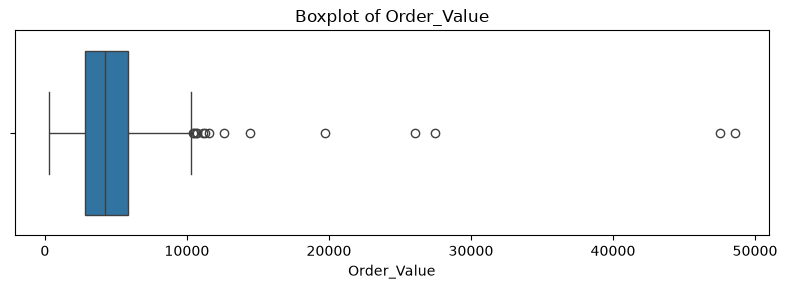

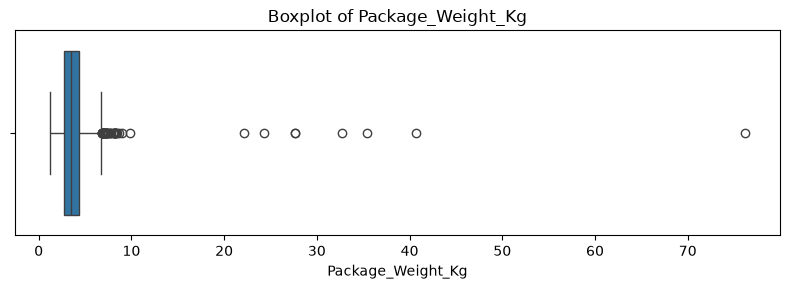

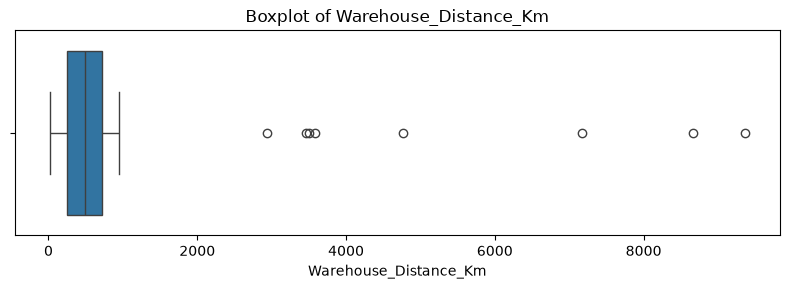

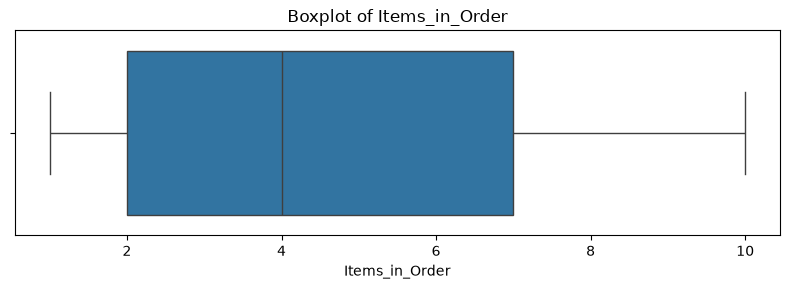

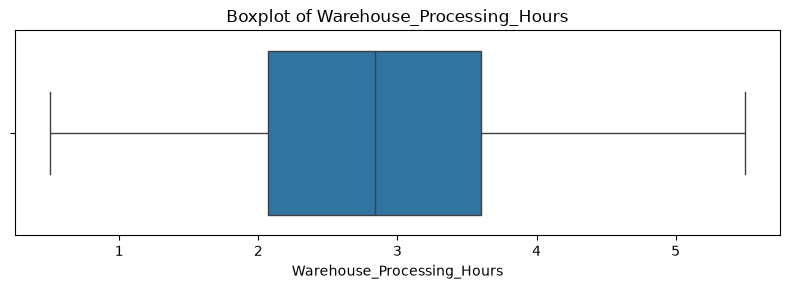

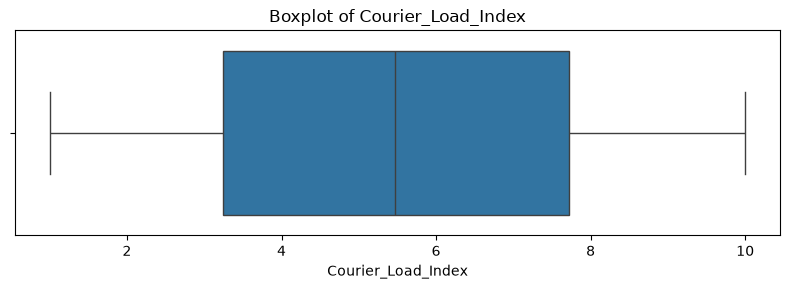

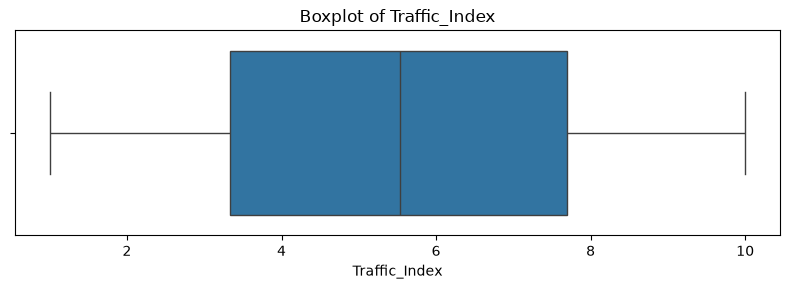

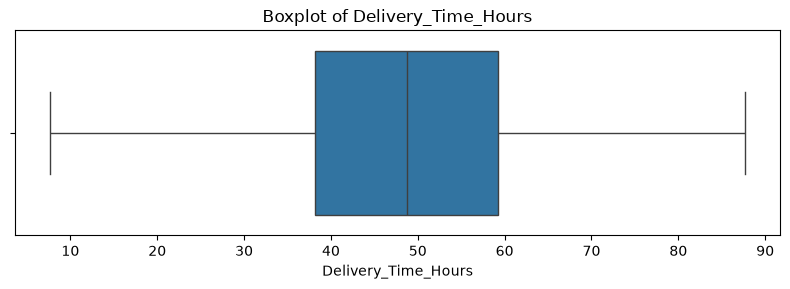

In [32]:
# ============================================================
# BOXPLOTS FOR NUMERICAL VARIABLES
# ============================================================

# Create one boxplot at a time so every variable
# is clearly visible in the notebook.

for column in numerical_predictors + [target_column]:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=df_clean[column]
    )

    plt.title(
        f"Boxplot of {column}"
    )

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [33]:
# ============================================================
# CREATE TEMPORARY DATASET FOR ASSUMPTION ANALYSIS
# ============================================================

# Create another copy so the main cleaned dataset remains unchanged
df_assumption = df_clean.copy()


# ------------------------------------------------------------
# TEMPORARY NUMERICAL IMPUTATION
# ------------------------------------------------------------

# For assumption analysis only:
# replace missing numerical predictor values with the median.

for column in numerical_predictors:

    median_value = df_assumption[column].median()

    df_assumption[column] = (
        df_assumption[column]
        .fillna(median_value)
    )


# ------------------------------------------------------------
# TEMPORARY CATEGORICAL IMPUTATION
# ------------------------------------------------------------

# Replace missing categorical values with the most frequent
# category (mode).

for column in categorical_predictors:

    mode_value = (
        df_assumption[column]
        .mode(dropna=True)
        .iloc[0]
    )

    df_assumption[column] = (
        df_assumption[column]
        .fillna(mode_value)
    )


# Verify that no missing values remain
print(
    "Missing values in temporary assumption dataset:",
    df_assumption.isnull().sum().sum()
)

print(
    "Shape:",
    df_assumption.shape
)

Missing values in temporary assumption dataset: 0
Shape: (3192, 11)


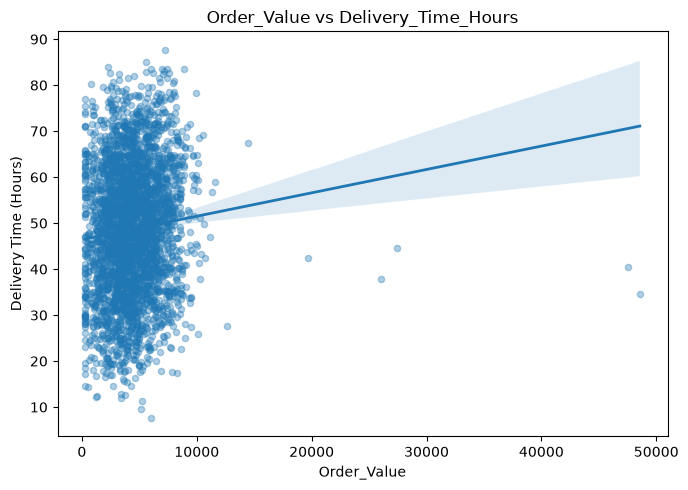

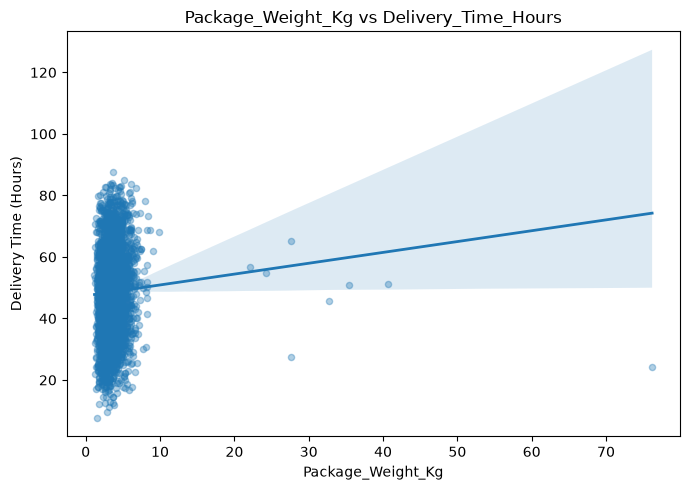

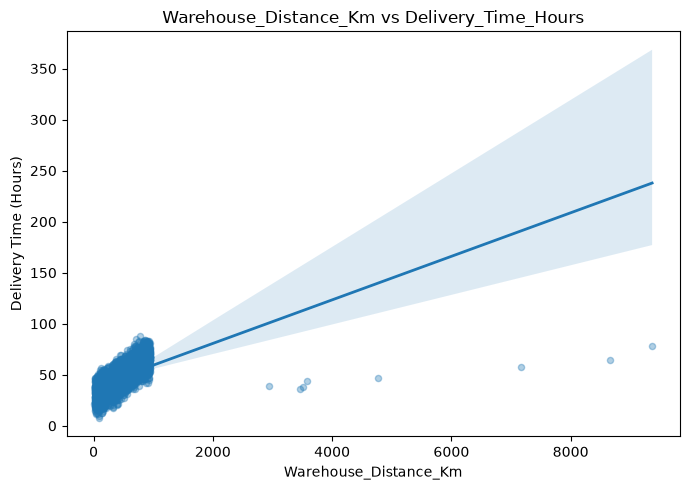

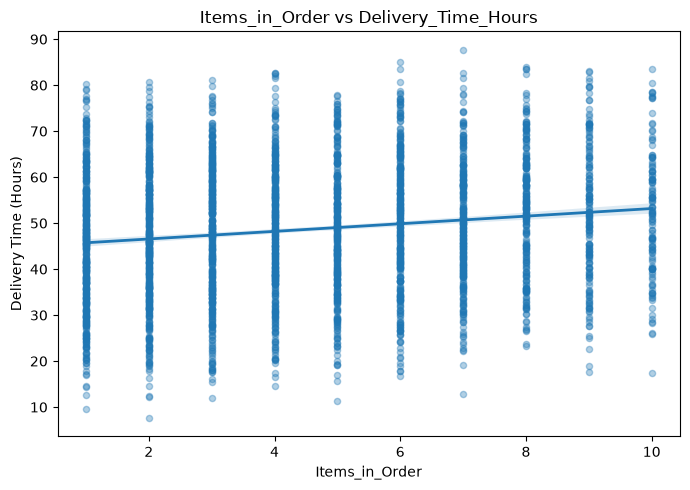

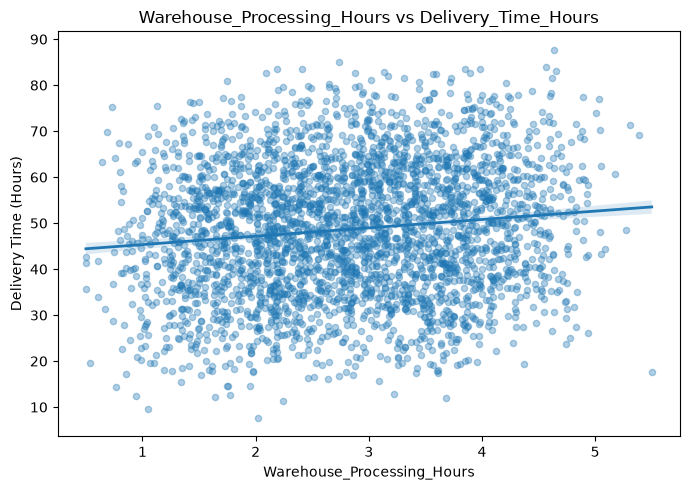

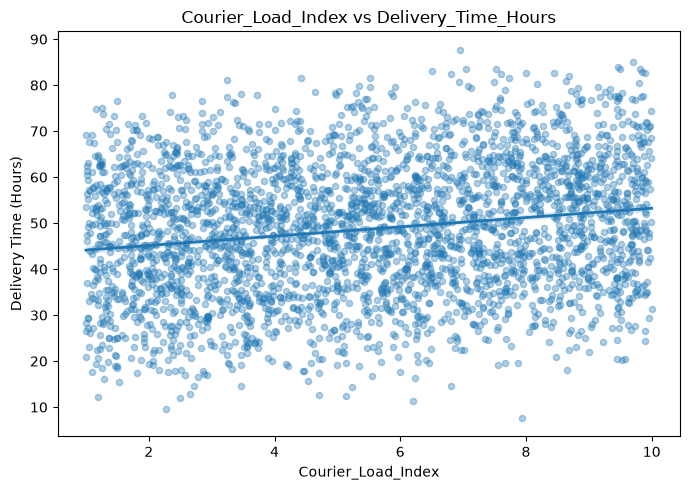

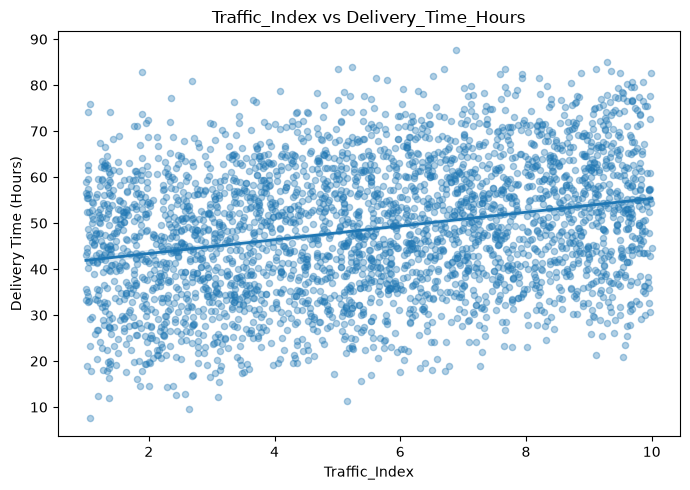

In [34]:
# ============================================================
# LINEARITY CHECK: PREDICTORS VS TARGET
# ============================================================

# Examine each numerical predictor against Delivery_Time_Hours.
#
# The extreme data-entry candidates are intentionally still present
# because we want to diagnose their effect before correcting them.

for column in numerical_predictors:

    plt.figure(figsize=(7, 5))

    sns.regplot(
        data=df_assumption,
        x=column,
        y=target_column,
        scatter_kws={
            "alpha": 0.35,
            "s": 20
        },
        line_kws={
            "linewidth": 2
        }
    )

    plt.title(
        f"{column} vs Delivery_Time_Hours"
    )

    plt.xlabel(column)
    plt.ylabel("Delivery Time (Hours)")

    plt.tight_layout()
    plt.show()

In [35]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# Select numerical predictors only.
# The target is included for understanding relationships,
# but multicollinearity itself concerns predictors.

correlation_columns = (
    numerical_predictors
    +
    [target_column]
)

correlation_matrix = (
    df_assumption[
        correlation_columns
    ]
    .corr()
)


# Display numerical matrix
display(
    correlation_matrix.round(3)
)

,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Items_in_Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic_Index,Delivery_Time_Hours
Order_Value,1.000,0.224,-0.027,0.548,0.214,0.024,-0.018,0.088
Package_Weight_Kg,0.224,1.000,-0.022,0.342,0.118,-0.005,0.002,0.054
Warehouse_Distance_Km,-0.027,-0.022,1.000,-0.000,0.002,0.003,0.026,0.574
Items_in_Order,0.548,0.342,-0.000,1.000,0.396,0.018,-0.016,0.153
Warehouse_Processing_Hours,0.214,0.118,0.002,0.396,1.000,0.029,0.014,0.125
Courier_Load_Index,0.024,-0.005,0.003,0.018,0.029,1.000,-0.010,0.184
Traffic_Index,-0.018,0.002,0.026,-0.016,0.014,-0.010,1.000,0.270
Delivery_Time_Hours,0.088,0.054,0.574,0.153,0.125,0.184,0.270,1.000


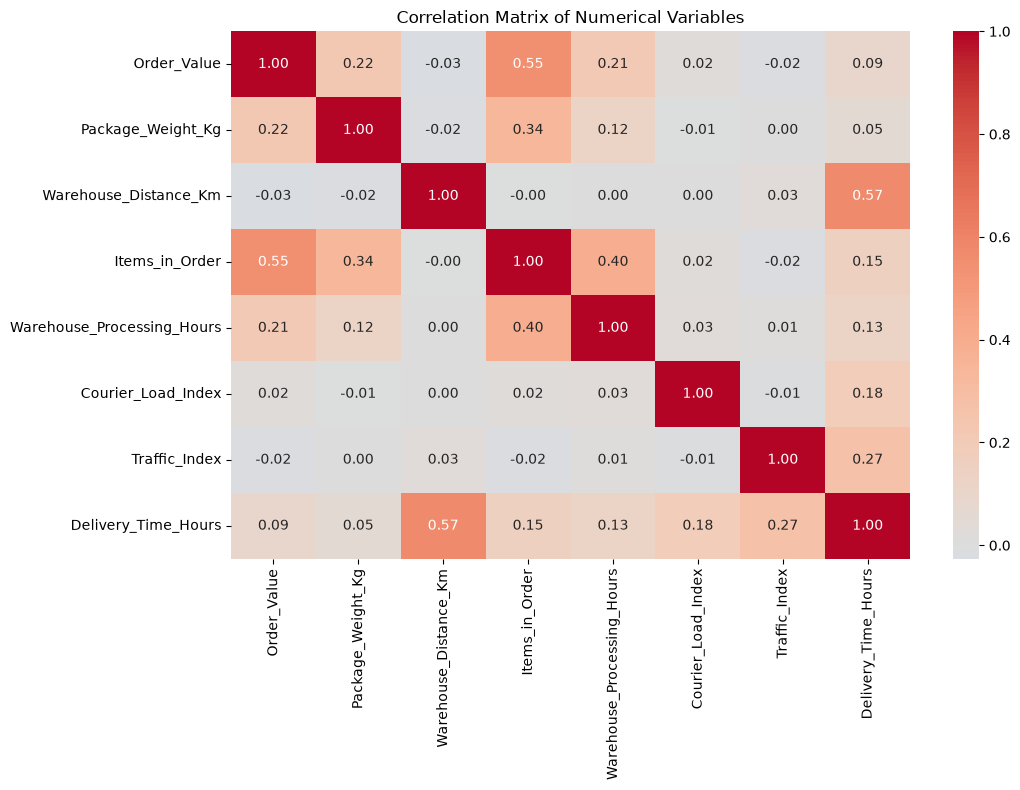

In [36]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(
    figsize=(11, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Numerical Variables"
)

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# PREPARE DATA FOR STATISTICAL REGRESSION
# ============================================================

# Select all predictors
X_assumption = df_assumption[
    numerical_predictors
    +
    categorical_predictors
].copy()


# Convert nominal categorical predictors into dummy variables.
#
# drop_first=True creates reference categories and avoids
# the dummy-variable trap.
X_assumption_encoded = pd.get_dummies(
    X_assumption,
    columns=categorical_predictors,
    drop_first=True,
    dtype=float
)


# Add an intercept for statsmodels OLS
X_assumption_ols = sm.add_constant(
    X_assumption_encoded
)


# Target variable
y_assumption = (
    df_assumption[target_column]
    .astype(float)
)


print(
    "Encoded predictor shape:",
    X_assumption_encoded.shape
)

print(
    "OLS design shape including constant:",
    X_assumption_ols.shape
)


print("\nEncoded Predictor Columns:")

for column in X_assumption_encoded.columns:
    print("-", column)

Encoded predictor shape: (3192, 13)
OLS design shape including constant: (3192, 14)

Encoded Predictor Columns:
- Order_Value
- Package_Weight_Kg
- Warehouse_Distance_Km
- Items_in_Order
- Warehouse_Processing_Hours
- Courier_Load_Index
- Traffic_Index
- Product_Category_Books
- Product_Category_Electronics
- Product_Category_Fashion
- Product_Category_Home & Kitchen
- Shipping_Mode_Same-Day
- Shipping_Mode_Standard


In [38]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF)
# ============================================================

vif_results = []


# Start at column 1 rather than 0
# because column 0 is the regression constant/intercept.
for i in range(
    1,
    X_assumption_ols.shape[1]
):

    feature_name = (
        X_assumption_ols.columns[i]
    )

    vif_value = variance_inflation_factor(
        X_assumption_ols.values,
        i
    )

    vif_results.append(
        {
            "Feature": feature_name,
            "VIF": vif_value
        }
    )


# Convert results to table
vif_table = pd.DataFrame(
    vif_results
)


# Sort from highest to lowest VIF
vif_table = (
    vif_table
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    vif_table.round(3)
)

,Feature,VIF
0,Items_in_Order,1.797
1,Product_Category_Electronics,1.687
2,Product_Category_Home & Kitchen,1.670
3,Product_Category_Fashion,1.640
4,Product_Category_Books,1.625
5,Order_Value,1.531
6,Shipping_Mode_Same-Day,1.365
7,Shipping_Mode_Standard,1.362
8,Warehouse_Processing_Hours,1.189
9,Package_Weight_Kg,1.161


In [39]:
# ============================================================
# INITIAL MULTIPLE LINEAR REGRESSION - OLS
# ============================================================

# Fit Ordinary Least Squares regression using:
# - the temporarily imputed dataset
# - one-hot encoded categorical variables
# - all current extreme observations still present
#
# This is intentionally the BEFORE-CORRECTION model.

initial_ols_model = sm.OLS(
    y_assumption,
    X_assumption_ols
).fit()


# Display the complete statistical regression summary
print(initial_ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Delivery_Time_Hours   R-squared:                       0.616
Model:                             OLS   Adj. R-squared:                  0.614
Method:                  Least Squares   F-statistic:                     391.8
Date:                 Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                         13:35:42   Log-Likelihood:                -11488.
No. Observations:                 3192   AIC:                         2.300e+04
Df Residuals:                     3178   BIC:                         2.309e+04
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------


In [40]:
# ============================================================
# CREATE INITIAL FITTED VALUES AND RESIDUALS
# ============================================================

# Predicted/fitted values from the initial OLS regression
initial_fitted_values = initial_ols_model.fittedvalues

# Residual = Actual Delivery Time - Predicted Delivery Time
initial_residuals = initial_ols_model.resid


print("Number of fitted values:", len(initial_fitted_values))
print("Number of residuals:", len(initial_residuals))

Number of fitted values: 3192
Number of residuals: 3192


In [41]:
# ============================================================
# INITIAL MODEL R-SQUARED
# ============================================================

# R-squared shows the proportion of variation in delivery time
# explained by the current regression model.
initial_r2 = initial_ols_model.rsquared

# Adjusted R-squared also considers the number of predictors.
initial_adjusted_r2 = initial_ols_model.rsquared_adj


print("Initial R-squared:", round(initial_r2, 6))

print(
    "Initial Adjusted R-squared:",
    round(initial_adjusted_r2, 6)
)

Initial R-squared: 0.615779
Initial Adjusted R-squared: 0.614207


In [42]:
# ============================================================
# MEAN OF RESIDUALS
# ============================================================

# In OLS regression with an intercept, the residual mean
# should be extremely close to zero.
initial_mean_residual = np.mean(
    initial_residuals
)

print(
    "Mean of Residuals:",
    initial_mean_residual
)

Mean of Residuals: 3.873731188228557e-12


In [43]:
# ============================================================
# DURBIN-WATSON TEST
# ============================================================

# Durbin-Watson is used as a diagnostic for first-order
# autocorrelation in regression residuals.
initial_dw = durbin_watson(
    initial_residuals
)

print(
    "Durbin-Watson Statistic:",
    round(initial_dw, 6)
)

Durbin-Watson Statistic: 2.03123


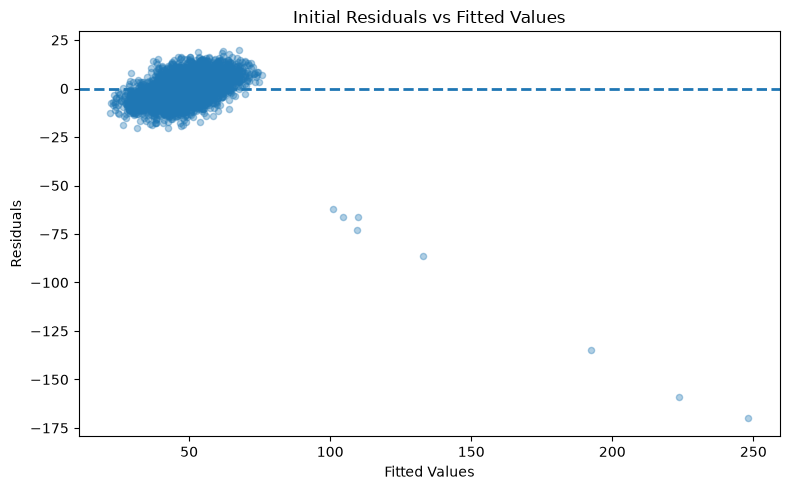

In [44]:
# ============================================================
# RESIDUALS VS FITTED VALUES
# ============================================================

plt.figure(
    figsize=(8, 5)
)

# Plot predicted values against regression residuals
plt.scatter(
    initial_fitted_values,
    initial_residuals,
    alpha=0.35,
    s=20
)

# Zero-residual reference line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Initial Residuals vs Fitted Values"
)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# BREUSCH-PAGAN TEST FOR HOMOSCEDASTICITY
# ============================================================

# Run the Breusch-Pagan test using:
# residuals from the initial model
# and the complete OLS design matrix.
bp_test = het_breuschpagan(
    initial_residuals,
    initial_ols_model.model.exog
)


# Extract the four returned statistics
bp_lm_statistic = bp_test[0]
bp_lm_pvalue = bp_test[1]
bp_f_statistic = bp_test[2]
bp_f_pvalue = bp_test[3]


print(
    "Breusch-Pagan LM Statistic:",
    bp_lm_statistic
)

print(
    "Breusch-Pagan LM p-value:",
    bp_lm_pvalue
)

print(
    "Breusch-Pagan F Statistic:",
    bp_f_statistic
)

print(
    "Breusch-Pagan F p-value:",
    bp_f_pvalue
)

Breusch-Pagan LM Statistic: 1559.2514501420617
Breusch-Pagan LM p-value: 0.0
Breusch-Pagan F Statistic: 233.45726344897292
Breusch-Pagan F p-value: 0.0


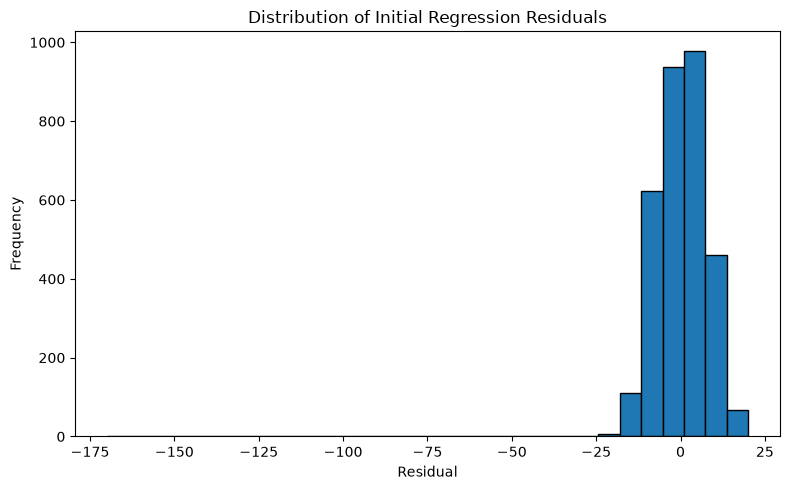

In [46]:
# ============================================================
# HISTOGRAM OF INITIAL RESIDUALS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    initial_residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Initial Regression Residuals"
)

plt.tight_layout()
plt.show()

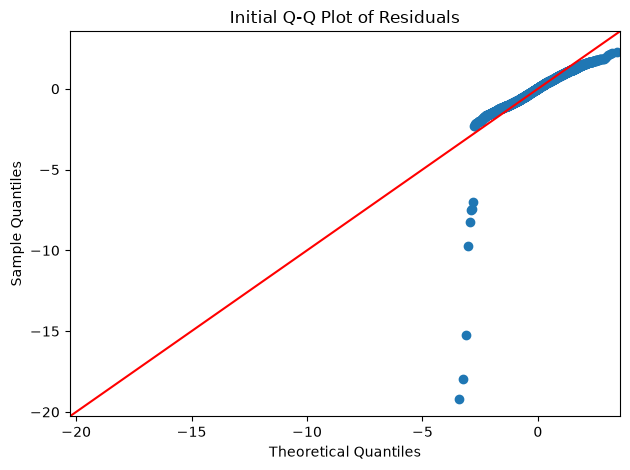

In [47]:
# ============================================================
# Q-Q PLOT OF INITIAL RESIDUALS
# ============================================================

# Compare observed residual quantiles against
# theoretical normal-distribution quantiles.
sm.qqplot(
    initial_residuals,
    line="45",
    fit=True
)

plt.title(
    "Initial Q-Q Plot of Residuals"
)

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# JARQUE-BERA NORMALITY TEST
# ============================================================

# Test residual normality using skewness and kurtosis.
(
    initial_jb_statistic,
    initial_jb_pvalue,
    initial_skewness,
    initial_kurtosis
) = jarque_bera(
    initial_residuals
)


print(
    "Jarque-Bera Statistic:",
    initial_jb_statistic
)

print(
    "Jarque-Bera p-value:",
    initial_jb_pvalue
)

print(
    "Residual Skewness:",
    initial_skewness
)

print(
    "Residual Kurtosis:",
    initial_kurtosis
)

Jarque-Bera Statistic: 1269972.0563714306
Jarque-Bera p-value: 0.0
Residual Skewness: -5.946849684419866
Residual Kurtosis: 99.99073148143766


In [49]:
# ============================================================
# INFLUENCE DIAGNOSTICS
# ============================================================

# Obtain regression influence statistics
initial_influence = (
    initial_ols_model
    .get_influence()
)


# Standardized residuals
initial_standardized_residuals = (
    initial_influence
    .resid_studentized_internal
)


# Leverage values
initial_leverage = (
    initial_influence
    .hat_matrix_diag
)


# Cook's Distance
initial_cooks_distance = (
    initial_influence
    .cooks_distance[0]
)


print(
    "Influence diagnostics calculated successfully."
)

Influence diagnostics calculated successfully.


In [50]:
# ============================================================
# CREATE INITIAL INFLUENCE TABLE
# ============================================================

initial_diagnostics = df_assumption[
    [
        "Order_ID",
        "Order_Value",
        "Package_Weight_Kg",
        "Warehouse_Distance_Km",
        "Delivery_Time_Hours"
    ]
].copy()


# Add fitted/predicted delivery time
initial_diagnostics["Predicted"] = (
    initial_fitted_values.values
)


# Add raw residuals
initial_diagnostics["Residual"] = (
    initial_residuals.values
)


# Add standardized residuals
initial_diagnostics["Std_Residual"] = (
    initial_standardized_residuals
)


# Add leverage
initial_diagnostics["Leverage"] = (
    initial_leverage
)


# Add Cook's Distance
initial_diagnostics["Cooks_Distance"] = (
    initial_cooks_distance
)


print(
    "Diagnostic table created:",
    initial_diagnostics.shape
)

Diagnostic table created: (3192, 10)


In [51]:
# ============================================================
# LARGEST STANDARDIZED RESIDUALS
# ============================================================

# Create an absolute-value column only for sorting.
initial_diagnostics[
    "Abs_Std_Residual"
] = (
    initial_diagnostics["Std_Residual"]
    .abs()
)


# Display the 15 most extreme residual observations
largest_residuals = (
    initial_diagnostics
    .sort_values(
        "Abs_Std_Residual",
        ascending=False
    )
    .head(15)
)


display(
    largest_residuals[
        [
            "Order_ID",
            "Warehouse_Distance_Km",
            "Delivery_Time_Hours",
            "Predicted",
            "Residual",
            "Std_Residual"
        ]
    ]
)


# Count observations exceeding ±3
print(
    "Observations with |standardized residual| > 3:",
    (
        initial_diagnostics[
            "Abs_Std_Residual"
        ] > 3
    ).sum()
)

,Order_ID,Warehouse_Distance_Km,Delivery_Time_Hours,Predicted,Residual,Std_Residual
960,ORD100962,9366.0,78.24,248.142533,-169.902533,-21.034054
2649,ORD102656,8667.0,64.90,223.724585,-158.824585,-19.374856
2490,ORD102497,7167.0,57.61,192.395994,-134.785994,-16.004276
2624,ORD102631,4764.0,46.62,132.750921,-86.130921,-9.927605
1828,ORD101832,3465.0,36.47,109.631869,-73.161869,-8.343967
2271,ORD102277,3507.0,38.20,104.380344,-66.180344,-7.553744
2585,ORD102592,3578.0,43.63,109.686493,-66.056493,-7.539294
587,ORD100589,2944.0,38.95,100.914904,-61.964904,-7.049904
1386,ORD101389,40.5,11.37,31.677985,-20.307985,-2.294203
2758,ORD102765,27.1,22.18,42.370741,-20.190741,-2.281692


Observations with |standardized residual| > 3: 8


In [52]:
# ============================================================
# LEVERAGE ANALYSIS
# ============================================================

# k = total number of regression parameters,
# including the intercept.
k_parameters = (
    X_assumption_ols.shape[1]
)

# n = total number of observations
n_observations = (
    X_assumption_ols.shape[0]
)


# Common screening threshold:
# 2k / n
leverage_threshold = (
    2
    *
    k_parameters
    /
    n_observations
)


print(
    "Leverage Threshold:",
    leverage_threshold
)


# Identify high-leverage observations
high_leverage = (
    initial_diagnostics[
        initial_diagnostics[
            "Leverage"
        ] > leverage_threshold
    ]
    .sort_values(
        "Leverage",
        ascending=False
    )
)


print(
    "Number of High-Leverage Observations:",
    len(high_leverage)
)


display(
    high_leverage[
        [
            "Order_ID",
            "Order_Value",
            "Package_Weight_Kg",
            "Warehouse_Distance_Km",
            "Leverage",
            "Cooks_Distance"
        ]
    ].head(20)
)

Leverage Threshold: 0.008771929824561403
Number of High-Leverage Observations: 22


,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Leverage,Cooks_Distance
1751,ORD101754,4717.0,76.20,71.6,0.405131,0.039033
960,ORD100962,3724.0,4.27,9366.0,0.169822,6.464563
641,ORD100643,48570.0,4.79,93.8,0.150295,0.037637
2649,ORD102656,3182.0,2.21,8667.0,0.144980,4.546539
2539,ORD102546,47510.0,3.80,364.9,0.142419,0.000207
1523,ORD101526,4038.0,40.70,247.3,0.109420,0.009361
2490,ORD102497,1891.0,4.63,7167.0,0.097525,1.977080
444,ORD100446,6815.0,35.40,426.6,0.076457,0.003329
610,ORD100612,6368.0,32.70,537.4,0.065690,0.000291
1995,ORD102000,27440.0,3.60,387.3,0.054123,0.000486


In [53]:
# ============================================================
# COOK'S DISTANCE ANALYSIS
# ============================================================

# Calculate screening threshold
cooks_threshold = (
    4
    /
    n_observations
)


print(
    "Cook's Distance Threshold:",
    cooks_threshold
)


# Identify observations exceeding the screening threshold
high_cooks = (
    initial_diagnostics[
        initial_diagnostics[
            "Cooks_Distance"
        ] > cooks_threshold
    ]
    .sort_values(
        "Cooks_Distance",
        ascending=False
    )
)


print(
    "Observations Above Cook's Threshold:",
    len(high_cooks)
)


display(
    high_cooks[
        [
            "Order_ID",
            "Order_Value",
            "Package_Weight_Kg",
            "Warehouse_Distance_Km",
            "Std_Residual",
            "Leverage",
            "Cooks_Distance"
        ]
    ].head(20)
)

Cook's Distance Threshold: 0.0012531328320802004
Observations Above Cook's Threshold: 26


,Order_ID,Order_Value,Package_Weight_Kg,Warehouse_Distance_Km,Std_Residual,Leverage,Cooks_Distance
960,ORD100962,3724.0,4.27,9366.0,-21.034054,0.169822,6.464563
2649,ORD102656,3182.0,2.21,8667.0,-19.374856,0.144980,4.546539
2490,ORD102497,1891.0,4.63,7167.0,-16.004276,0.097525,1.977080
2624,ORD102631,2935.0,2.82,4764.0,-9.927605,0.042261,0.310641
1828,ORD101832,6093.0,2.47,3465.0,-8.343967,0.021767,0.110657
2271,ORD102277,3058.0,2.97,3507.0,-7.553744,0.023322,0.097323
2585,ORD102592,2443.0,2.71,3578.0,-7.539294,0.023241,0.096605
587,ORD100589,7021.0,4.70,2944.0,-7.049904,0.017024,0.061483
1751,ORD101754,4717.0,76.20,71.6,-0.895767,0.405131,0.039033
641,ORD100643,48570.0,4.79,93.8,-1.725972,0.150295,0.037637


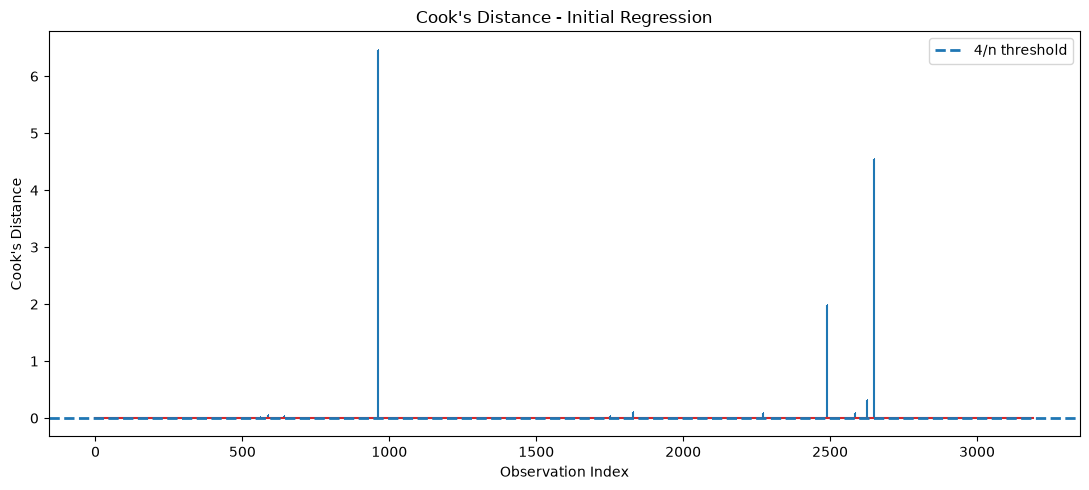

In [54]:
# ============================================================
# COOK'S DISTANCE PLOT
# ============================================================

plt.figure(
    figsize=(11, 5)
)


plt.stem(
    np.arange(
        len(initial_cooks_distance)
    ),
    initial_cooks_distance,
    markerfmt=","
)


# Add the 4/n screening threshold
plt.axhline(
    y=cooks_threshold,
    linestyle="--",
    linewidth=2,
    label="4/n threshold"
)


plt.xlabel(
    "Observation Index"
)

plt.ylabel(
    "Cook's Distance"
)

plt.title(
    "Cook's Distance - Initial Regression"
)

plt.legend()

plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# CREATE DATASET FOR CONFIRMED DATA-ENTRY CORRECTIONS
# ============================================================

# Preserve df_clean as the pre-correction cleaned dataset.
# All confirmed data-entry corrections will be made
# in a separate DataFrame.
df_corrected = df_clean.copy()

print("Correction dataset created.")

print(
    "Shape:",
    df_corrected.shape
)

Correction dataset created.
Shape: (3192, 11)


In [56]:
# ============================================================
# DEFINE CONFIRMED x10 DATA-ENTRY ERRORS
# ============================================================

# Each entry contains:
#
# Order_ID : (current incorrect value, correct value)
#
# We explicitly state BOTH values so that the notebook can
# verify the current data before making any correction.

confirmed_corrections = {

    # --------------------------------------------------------
    # ORDER VALUE: 8 CONFIRMED x10 ERRORS
    # --------------------------------------------------------
    "Order_Value": {

        "ORD100023": (14420.0, 1442.0),
        "ORD100643": (48570.0, 4857.0),
        "ORD100793": (3000.0, 300.0),
        "ORD101636": (19700.0, 1970.0),
        "ORD102000": (27440.0, 2744.0),
        "ORD102337": (3000.0, 300.0),
        "ORD102528": (26040.0, 2604.0),
        "ORD102546": (47510.0, 4751.0)
    },


    # --------------------------------------------------------
    # PACKAGE WEIGHT: 8 CONFIRMED x10 ERRORS
    # --------------------------------------------------------
    "Package_Weight_Kg": {

        "ORD100446": (35.40, 3.54),
        "ORD100562": (27.60, 2.76),
        "ORD100612": (32.70, 3.27),
        "ORD101526": (40.70, 4.07),
        "ORD101624": (27.60, 2.76),
        "ORD101754": (76.20, 7.62),
        "ORD101941": (22.10, 2.21),
        "ORD103062": (24.30, 2.43)
    },


    # --------------------------------------------------------
    # WAREHOUSE DISTANCE: 8 CONFIRMED x10 ERRORS
    # --------------------------------------------------------
    "Warehouse_Distance_Km": {

        "ORD100589": (2944.0, 294.4),
        "ORD100962": (9366.0, 936.6),
        "ORD101832": (3465.0, 346.5),
        "ORD102277": (3507.0, 350.7),
        "ORD102497": (7167.0, 716.7),
        "ORD102592": (3578.0, 357.8),
        "ORD102631": (4764.0, 476.4),
        "ORD102656": (8667.0, 866.7)
    }
}


# Count how many corrections have been specified
number_of_corrections = sum(
    len(values)
    for values in confirmed_corrections.values()
)


print(
    "Confirmed corrections specified:",
    number_of_corrections
)

Confirmed corrections specified: 24


In [57]:
# ============================================================
# VERIFY ALL CONFIRMED CORRECTIONS BEFORE APPLYING THEM
# ============================================================

correction_check = []


for column, order_mapping in confirmed_corrections.items():

    for order_id, values in order_mapping.items():

        expected_bad_value = values[0]
        corrected_value = values[1]

        # Locate the specified Order_ID
        mask = (
            df_corrected["Order_ID"]
            ==
            order_id
        )


        # There must be exactly one matching observation
        match_count = int(mask.sum())

        assert match_count == 1, (
            f"{order_id} was expected exactly once, "
            f"but {match_count} matches were found."
        )


        # Read the value currently stored in the dataset
        current_value = (
            df_corrected
            .loc[mask, column]
            .iloc[0]
        )


        # It must not be missing
        assert pd.notna(current_value), (
            f"{order_id} has a missing value in {column}."
        )


        # Verify current value matches the known bad entry
        assert np.isclose(
            float(current_value),
            float(expected_bad_value)
        ), (
            f"Unexpected value for {order_id} in {column}. "
            f"Expected {expected_bad_value}, "
            f"found {current_value}."
        )


        # Save verification information
        correction_check.append(
            {
                "Order_ID": order_id,
                "Column": column,
                "Current_Value": current_value,
                "Corrected_Value": corrected_value
            }
        )


# Convert to a table
correction_check = pd.DataFrame(
    correction_check
)


display(correction_check)


print(
    "\nAll 24 correction checks passed successfully."
)

,Order_ID,Column,Current_Value,Corrected_Value
0,ORD100023,Order_Value,14420.0,1442.00
1,ORD100643,Order_Value,48570.0,4857.00
2,ORD100793,Order_Value,3000.0,300.00
3,ORD101636,Order_Value,19700.0,1970.00
4,ORD102000,Order_Value,27440.0,2744.00
5,ORD102337,Order_Value,3000.0,300.00
6,ORD102528,Order_Value,26040.0,2604.00
7,ORD102546,Order_Value,47510.0,4751.00
8,ORD100446,Package_Weight_Kg,35.4,3.54
9,ORD100562,Package_Weight_Kg,27.6,2.76



All 24 correction checks passed successfully.


In [58]:
# ============================================================
# APPLY CONFIRMED DATA-ENTRY CORRECTIONS
# ============================================================

for column, order_mapping in confirmed_corrections.items():

    for order_id, values in order_mapping.items():

        # Extract the confirmed corrected value
        corrected_value = values[1]

        # Locate the correct observation
        mask = (
            df_corrected["Order_ID"]
            ==
            order_id
        )

        # Replace ONLY the confirmed incorrect field
        df_corrected.loc[
            mask,
            column
        ] = corrected_value


print(
    "All 24 confirmed data-entry errors corrected successfully."
)

All 24 confirmed data-entry errors corrected successfully.


In [59]:
# ============================================================
# VERIFY CORRECTED VALUES
# ============================================================

correction_verification = []


for column, order_mapping in confirmed_corrections.items():

    for order_id, values in order_mapping.items():

        corrected_value_expected = values[1]

        actual_value = (
            df_corrected
            .loc[
                df_corrected["Order_ID"] == order_id,
                column
            ]
            .iloc[0]
        )


        correction_verification.append(
            {
                "Order_ID": order_id,
                "Column": column,
                "Expected_Corrected_Value":
                    corrected_value_expected,
                "Actual_Value_After_Correction":
                    actual_value,
                "Correct":
                    np.isclose(
                        float(actual_value),
                        float(corrected_value_expected)
                    )
            }
        )


correction_verification = pd.DataFrame(
    correction_verification
)


display(correction_verification)


print(
    "\nAll corrections verified:",
    correction_verification["Correct"].all()
)

,Order_ID,Column,Expected_Corrected_Value,Actual_Value_After_Correction,Correct
0,ORD100023,Order_Value,1442.00,1442.00,True
1,ORD100643,Order_Value,4857.00,4857.00,True
2,ORD100793,Order_Value,300.00,300.00,True
3,ORD101636,Order_Value,1970.00,1970.00,True
4,ORD102000,Order_Value,2744.00,2744.00,True
5,ORD102337,Order_Value,300.00,300.00,True
6,ORD102528,Order_Value,2604.00,2604.00,True
7,ORD102546,Order_Value,4751.00,4751.00,True
8,ORD100446,Package_Weight_Kg,3.54,3.54,True
9,ORD100562,Package_Weight_Kg,2.76,2.76,True



All corrections verified: True


In [60]:
# ============================================================
# RE-CHECK IQR AFTER CONFIRMED CORRECTIONS
# ============================================================

corrected_iqr_results = []


for column in numerical_predictors + [target_column]:

    valid_values = (
        df_corrected[column]
        .dropna()
    )


    # Calculate quartiles
    Q1 = valid_values.quantile(0.25)

    Q3 = valid_values.quantile(0.75)

    IQR = Q3 - Q1


    # Calculate standard IQR bounds
    lower_bound = (
        Q1
        -
        1.5 * IQR
    )

    upper_bound = (
        Q3
        +
        1.5 * IQR
    )


    # Count remaining statistical outliers
    outlier_count = (
        (
            (df_corrected[column] < lower_bound)
            |
            (df_corrected[column] > upper_bound)
        )
        .sum()
    )


    corrected_iqr_results.append(
        {
            "Column": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Potential_Outliers":
                int(outlier_count)
        }
    )


corrected_iqr_summary = pd.DataFrame(
    corrected_iqr_results
)


display(
    corrected_iqr_summary.round(4)
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,Order_Value,2824.7500,5798.000,2973.2500,-1635.1250,10257.8750,10
1,Package_Weight_Kg,2.7000,4.320,1.6200,0.2700,6.7500,42
2,Warehouse_Distance_Km,251.8750,711.000,459.1250,-436.8125,1399.6875,0
3,Items_in_Order,2.0000,7.000,5.0000,-5.5000,14.5000,0
4,Warehouse_Processing_Hours,2.0700,3.600,1.5300,-0.2250,5.8950,0
5,Courier_Load_Index,3.2400,7.720,4.4800,-3.4800,14.4400,0
6,Traffic_Index,3.3300,7.700,4.3700,-3.2250,14.2550,0
7,Delivery_Time_Hours,38.1925,59.255,21.0625,6.5988,90.8488,0


In [61]:
# ============================================================
# CREATE FINAL ASSUMPTION DATASET
# ============================================================

# Copy the corrected dataset
final_assumption_df = (
    df_corrected.copy()
)


# ------------------------------------------------------------
# TEMPORARY NUMERICAL IMPUTATION
# ------------------------------------------------------------

for column in numerical_predictors:

    median_value = (
        final_assumption_df[column]
        .median()
    )

    final_assumption_df[column] = (
        final_assumption_df[column]
        .fillna(median_value)
    )


# ------------------------------------------------------------
# TEMPORARY CATEGORICAL IMPUTATION
# ------------------------------------------------------------

for column in categorical_predictors:

    mode_value = (
        final_assumption_df[column]
        .mode(dropna=True)
        .iloc[0]
    )

    final_assumption_df[column] = (
        final_assumption_df[column]
        .fillna(mode_value)
    )


# Verify completion
print(
    "Missing values in final assumption dataset:",
    final_assumption_df.isnull().sum().sum()
)

print(
    "Final assumption dataset shape:",
    final_assumption_df.shape
)

Missing values in final assumption dataset: 0
Final assumption dataset shape: (3192, 11)


In [62]:
# ============================================================
# PREPARE FINAL ASSUMPTION REGRESSION DATA
# ============================================================

# Select predictor columns
X_final_assumption = final_assumption_df[
    numerical_predictors
    +
    categorical_predictors
].copy()


# One-hot encode categorical predictors
X_final_encoded = pd.get_dummies(
    X_final_assumption,
    columns=categorical_predictors,
    drop_first=True,
    dtype=float
)


# Add regression intercept
X_final_ols = sm.add_constant(
    X_final_encoded
)


# Define target
y_final_assumption = (
    final_assumption_df[
        target_column
    ]
    .astype(float)
)


print(
    "Final encoded predictor shape:",
    X_final_encoded.shape
)

print(
    "Final OLS design shape:",
    X_final_ols.shape
)

Final encoded predictor shape: (3192, 13)
Final OLS design shape: (3192, 14)


In [63]:
# ============================================================
# REFIT OLS AFTER DATA CORRECTIONS
# ============================================================

final_ols_model = sm.OLS(
    y_final_assumption,
    X_final_ols
).fit()


print(
    final_ols_model.summary()
)

                             OLS Regression Results                            
Dep. Variable:     Delivery_Time_Hours   R-squared:                       0.925
Model:                             OLS   Adj. R-squared:                  0.925
Method:                  Least Squares   F-statistic:                     3031.
Date:                 Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                         13:48:09   Log-Likelihood:                -8872.4
No. Observations:                 3192   AIC:                         1.777e+04
Df Residuals:                     3178   BIC:                         1.786e+04
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------


In [64]:
# ============================================================
# FINAL FITTED VALUES AND RESIDUALS
# ============================================================

final_fitted_values = (
    final_ols_model.fittedvalues
)

final_assumption_residuals = (
    final_ols_model.resid
)


print(
    "Fitted Values:",
    len(final_fitted_values)
)

print(
    "Residuals:",
    len(final_assumption_residuals)
)

Fitted Values: 3192
Residuals: 3192


In [65]:
# ============================================================
# FINAL MEAN OF RESIDUALS
# ============================================================

final_mean_residual = np.mean(
    final_assumption_residuals
)


print(
    "Final Mean of Residuals:",
    final_mean_residual
)

Final Mean of Residuals: -7.550629572989535e-15


In [66]:
# ============================================================
# FINAL DURBIN-WATSON
# ============================================================

final_dw = durbin_watson(
    final_assumption_residuals
)


print(
    "Final Durbin-Watson Statistic:",
    round(final_dw, 6)
)

Final Durbin-Watson Statistic: 1.982046


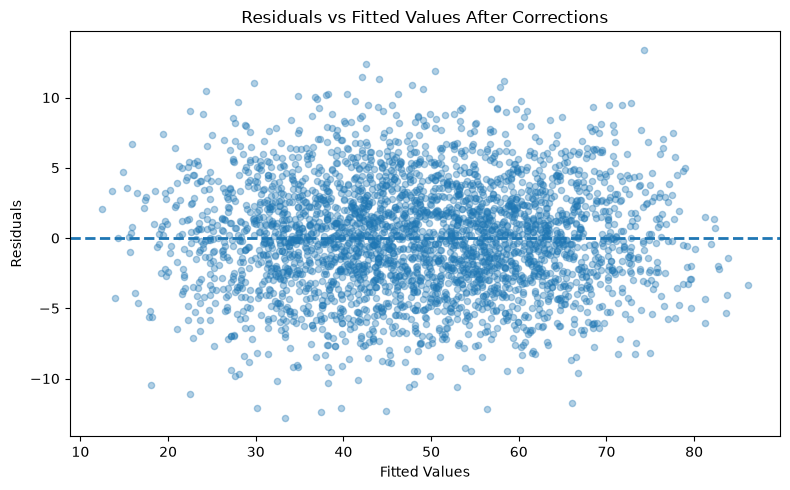

In [67]:
# ============================================================
# FINAL RESIDUALS VS FITTED VALUES
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.scatter(
    final_fitted_values,
    final_assumption_residuals,
    alpha=0.35,
    s=20
)


# Reference line at zero residual
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Fitted Values"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residuals vs Fitted Values After Corrections"
)

plt.tight_layout()
plt.show()

In [68]:
# ============================================================
# FINAL BREUSCH-PAGAN TEST
# ============================================================

final_bp_test = het_breuschpagan(
    final_assumption_residuals,
    final_ols_model.model.exog
)


final_bp_lm_statistic = (
    final_bp_test[0]
)

final_bp_lm_pvalue = (
    final_bp_test[1]
)

final_bp_f_statistic = (
    final_bp_test[2]
)

final_bp_f_pvalue = (
    final_bp_test[3]
)


print(
    "Final BP LM Statistic:",
    final_bp_lm_statistic
)

print(
    "Final BP LM p-value:",
    final_bp_lm_pvalue
)

print(
    "Final BP F Statistic:",
    final_bp_f_statistic
)

print(
    "Final BP F p-value:",
    final_bp_f_pvalue
)

Final BP LM Statistic: 14.988938504984738
Final BP LM p-value: 0.3080438299352968
Final BP F Statistic: 1.1533541734380055
Final BP F p-value: 0.30833936225844455


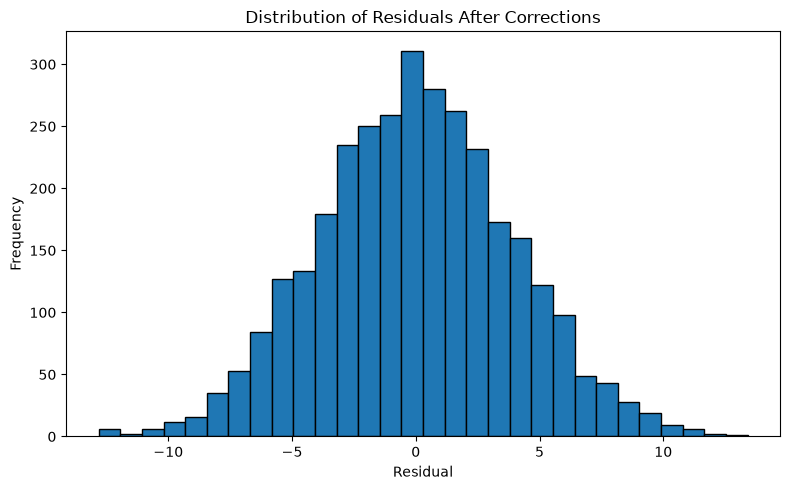

In [69]:
# ============================================================
# FINAL RESIDUAL HISTOGRAM
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(
    final_assumption_residuals,
    bins=30,
    edgecolor="black"
)


plt.xlabel(
    "Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Residuals After Corrections"
)

plt.tight_layout()
plt.show()

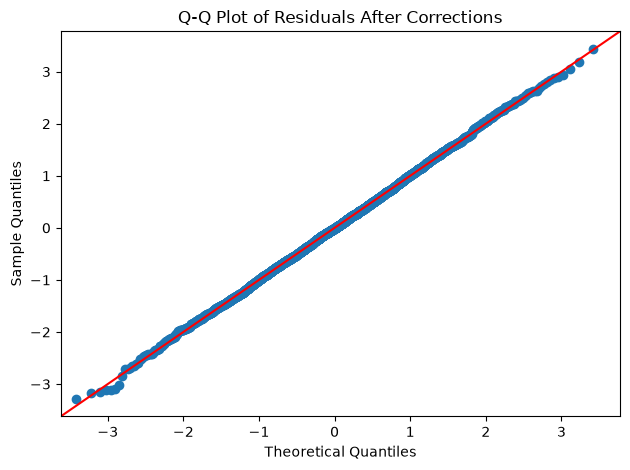

In [70]:
# ============================================================
# FINAL Q-Q PLOT
# ============================================================

sm.qqplot(
    final_assumption_residuals,
    line="45",
    fit=True
)


plt.title(
    "Q-Q Plot of Residuals After Corrections"
)

plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# FINAL JARQUE-BERA NORMALITY TEST
# ============================================================

(
    final_jb_statistic,
    final_jb_pvalue,
    final_skewness,
    final_kurtosis
) = jarque_bera(
    final_assumption_residuals
)


print(
    "Final Jarque-Bera Statistic:",
    final_jb_statistic
)

print(
    "Final Jarque-Bera p-value:",
    final_jb_pvalue
)

print(
    "Final Residual Skewness:",
    final_skewness
)

print(
    "Final Residual Kurtosis:",
    final_kurtosis
)

Final Jarque-Bera Statistic: 0.8897158400890761
Final Jarque-Bera p-value: 0.6409153307852908
Final Residual Skewness: 0.03217565818874046
Final Residual Kurtosis: 2.9495173211575496


In [72]:
# ============================================================
# BEFORE VS AFTER ASSUMPTION SUMMARY
# ============================================================

assumption_comparison = pd.DataFrame({

    "Diagnostic": [
        "R-squared",
        "Adjusted R-squared",
        "Durbin-Watson",
        "Breusch-Pagan p-value",
        "Jarque-Bera p-value",
        "Residual Skewness",
        "Residual Kurtosis"
    ],

    "Before Correction": [
        initial_ols_model.rsquared,
        initial_ols_model.rsquared_adj,
        initial_dw,
        bp_lm_pvalue,
        initial_jb_pvalue,
        initial_skewness,
        initial_kurtosis
    ],

    "After Correction": [
        final_ols_model.rsquared,
        final_ols_model.rsquared_adj,
        final_dw,
        final_bp_lm_pvalue,
        final_jb_pvalue,
        final_skewness,
        final_kurtosis
    ]
})


display(
    assumption_comparison.round(6)
)

,Diagnostic,Before Correction,After Correction
0,R-squared,0.615779,0.925365
1,Adjusted R-squared,0.614207,0.925060
2,Durbin-Watson,2.031230,1.982046
3,Breusch-Pagan p-value,0.000000,0.308044
4,Jarque-Bera p-value,0.000000,0.640915
5,Residual Skewness,-5.946850,0.032176
6,Residual Kurtosis,99.990731,2.949517


In [73]:
# ============================================================
# DEFINE FINAL FEATURES AND TARGET FOR MACHINE LEARNING
# ============================================================

# IMPORTANT:
# We use df_corrected rather than final_assumption_df.
#
# df_corrected still contains the remaining predictor NaN values.
# These will be handled INSIDE the sklearn Pipeline after
# train-test splitting, which helps prevent data leakage.


# Predictor matrix:
# include the 7 numerical predictors and 2 categorical predictors.
# Order_ID is intentionally excluded because it is only an identifier.
X = df_corrected[
    numerical_predictors
    +
    categorical_predictors
].copy()


# Target variable
y = (
    df_corrected[target_column]
    .astype(float)
    .copy()
)


print("X Shape:", X.shape)
print("y Shape:", y.shape)

print(
    "\nMissing predictor cells retained for Pipeline:",
    X.isnull().sum().sum()
)

print(
    "Missing target values:",
    y.isnull().sum()
)

X Shape: (3192, 9)
y Shape: (3192,)

Missing predictor cells retained for Pipeline: 104
Missing target values: 0


In [74]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

# Split the corrected observations:
#
# 80% → training data
# 20% → testing data
#
# random_state=42 makes the split reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print(
    "Training observations:",
    X_train.shape[0]
)

print(
    "Testing observations:",
    X_test.shape[0]
)

print(
    "\nTraining percentage:",
    round(
        X_train.shape[0] / X.shape[0] * 100,
        2
    )
)

print(
    "Testing percentage:",
    round(
        X_test.shape[0] / X.shape[0] * 100,
        2
    )
)

Training observations: 2553
Testing observations: 639

Training percentage: 79.98
Testing percentage: 20.02


In [75]:
# ============================================================
# NUMERICAL PREPROCESSING PIPELINE
# ============================================================

# Missing numerical predictor values will be replaced
# by the median learned during model fitting.
#
# Because this imputer sits inside the Pipeline,
# fitting model_pipeline on X_train means these medians
# are learned only from the training observations.

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [76]:
# ============================================================
# NUMERICAL PREPROCESSING PIPELINE
# ============================================================

# Missing numerical predictor values will be replaced
# by the median learned during model fitting.
#
# Because this imputer sits inside the Pipeline,
# fitting model_pipeline on X_train means these medians
# are learned only from the training observations.

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [78]:
# ============================================================
# CATEGORICAL PREPROCESSING PIPELINE
# ============================================================

# Step 1:
# missing categorical values are replaced with
# the most frequent training category.
#
# Step 2:
# OneHotEncoder converts categories into binary variables.
#
# drop="first":
# removes one reference category from each categorical predictor.
#
# handle_unknown="ignore":
# prevents the application from crashing if an unseen category
# reaches the encoder in the future.

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

In [79]:
# ============================================================
# COMBINE NUMERICAL AND CATEGORICAL PREPROCESSING
# ============================================================

# Apply:
#
# numerical_pipeline
# → numerical predictors
#
# categorical_pipeline
# → categorical predictors

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_predictors
        ),

        (
            "cat",
            categorical_pipeline,
            categorical_predictors
        )
    ]
)

In [80]:
# ============================================================
# BUILD FINAL MULTIPLE LINEAR REGRESSION PIPELINE
# ============================================================

# The complete workflow is:
#
# raw predictors
#       ↓
# missing-value treatment
#       ↓
# categorical encoding
#       ↓
# multiple linear regression

model_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)


print(
    "Machine-learning Pipeline created successfully."
)

Machine-learning Pipeline created successfully.


In [81]:
# ============================================================
# TRAIN THE FINAL MODEL
# ============================================================

# Fit the COMPLETE pipeline using training data only.
#
# This simultaneously learns:
# - numerical medians
# - categorical modes
# - one-hot encoding structure
# - regression coefficients

model_pipeline.fit(
    X_train,
    y_train
)


print(
    "Model trained successfully."
)

Model trained successfully.


In [82]:
# ============================================================
# GENERATE MODEL PREDICTIONS
# ============================================================

# Predictions for training observations
y_train_pred = model_pipeline.predict(
    X_train
)


# Predictions for unseen testing observations
y_test_pred = model_pipeline.predict(
    X_test
)


print(
    "Training predictions generated:",
    len(y_train_pred)
)

print(
    "Testing predictions generated:",
    len(y_test_pred)
)

Training predictions generated: 2553
Testing predictions generated: 639


In [83]:
# ============================================================
# GET FINAL TRANSFORMED FEATURE NAMES
# ============================================================

# Obtain the actual predictor names after preprocessing
transformed_feature_names = (
    model_pipeline
    .named_steps["preprocessing"]
    .get_feature_names_out()
)


# Number of predictors actually entering Linear Regression
number_of_transformed_predictors = len(
    transformed_feature_names
)


print(
    "Number of transformed predictors:",
    number_of_transformed_predictors
)


print(
    "\nTransformed Predictor Names:"
)

for feature in transformed_feature_names:
    print("-", feature)

Number of transformed predictors: 13

Transformed Predictor Names:
- num__Order_Value
- num__Package_Weight_Kg
- num__Warehouse_Distance_Km
- num__Items_in_Order
- num__Warehouse_Processing_Hours
- num__Courier_Load_Index
- num__Traffic_Index
- cat__Product_Category_Books
- cat__Product_Category_Electronics
- cat__Product_Category_Fashion
- cat__Product_Category_Home & Kitchen
- cat__Shipping_Mode_Same-Day
- cat__Shipping_Mode_Standard


In [84]:
# ============================================================
# TRAINING R-SQUARED AND ADJUSTED R-SQUARED
# ============================================================

# Training R-squared
train_r2 = r2_score(
    y_train,
    y_train_pred
)


# Number of training observations
n_train = len(y_train)


# Actual number of transformed predictors
p = number_of_transformed_predictors


# Adjusted R-squared formula
train_adjusted_r2 = (
    1
    -
    (
        (1 - train_r2)
        *
        (n_train - 1)
        /
        (n_train - p - 1)
    )
)


print(
    "Training R-squared:",
    round(train_r2, 6)
)

print(
    "Training Adjusted R-squared:",
    round(train_adjusted_r2, 6)
)

Training R-squared: 0.927116
Training Adjusted R-squared: 0.926743


In [85]:
# ============================================================
# TEST SET MODEL EVALUATION
# ============================================================

# R-squared
test_r2 = r2_score(
    y_test,
    y_test_pred
)


# Mean Absolute Error
test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)


# Mean Squared Error
test_mse = mean_squared_error(
    y_test,
    y_test_pred
)


# Root Mean Squared Error
test_rmse = np.sqrt(
    test_mse
)


print(
    "Test R-squared:",
    round(test_r2, 6)
)

print(
    "Test MAE:",
    round(test_mae, 6)
)

print(
    "Test MSE:",
    round(test_mse, 6)
)

print(
    "Test RMSE:",
    round(test_rmse, 6)
)

Test R-squared: 0.91774
Test MAE: 3.325331
Test MSE: 17.180302
Test RMSE: 4.144913


In [86]:
# ============================================================
# MODEL PERFORMANCE SUMMARY
# ============================================================

performance_summary = pd.DataFrame(
    {
        "Metric": [
            "Training R-squared",
            "Training Adjusted R-squared",
            "Test R-squared",
            "Test MAE",
            "Test MSE",
            "Test RMSE"
        ],

        "Value": [
            train_r2,
            train_adjusted_r2,
            test_r2,
            test_mae,
            test_mse,
            test_rmse
        ]
    }
)


display(
    performance_summary.round(6)
)

,Metric,Value
0,Training R-squared,0.927116
1,Training Adjusted R-squared,0.926743
2,Test R-squared,0.917740
3,Test MAE,3.325331
4,Test MSE,17.180302
5,Test RMSE,4.144913


In [87]:
# ============================================================
# CALCULATE TEST-SET RESIDUALS
# ============================================================

# Residual:
# actual delivery time - predicted delivery time
test_residuals = (
    y_test.values
    -
    y_test_pred
)


print(
    "Number of test residuals:",
    len(test_residuals)
)

print(
    "Mean test residual:",
    np.mean(test_residuals)
)

Number of test residuals: 639
Mean test residual: 0.14222286172764212


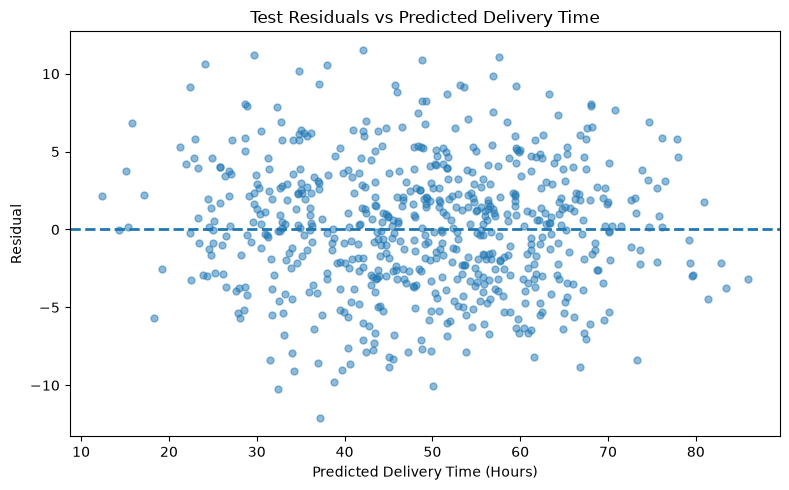

In [88]:
# ============================================================
# TEST RESIDUALS VS PREDICTED VALUES
# ============================================================

plt.figure(
    figsize=(8, 5)
)


# Plot test predictions against their residuals
plt.scatter(
    y_test_pred,
    test_residuals,
    alpha=0.5,
    s=25
)


# Zero-error reference line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Predicted Delivery Time (Hours)"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Test Residuals vs Predicted Delivery Time"
)

plt.tight_layout()
plt.show()

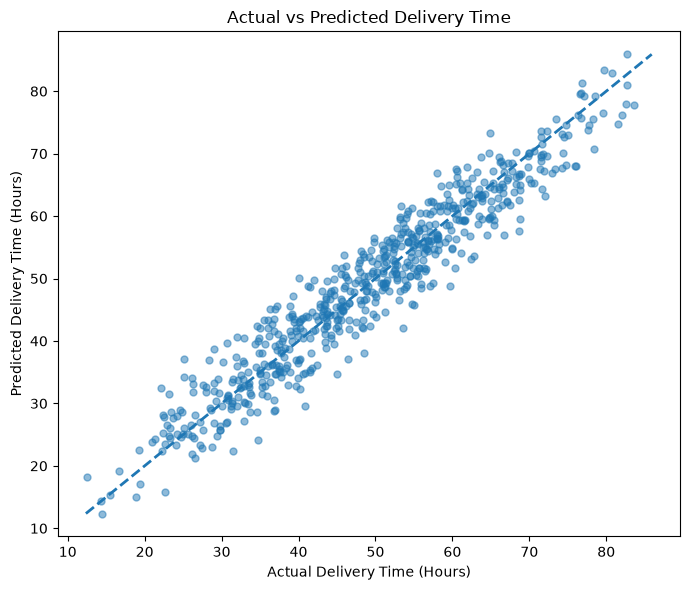

In [89]:
# ============================================================
# ACTUAL VS PREDICTED DELIVERY TIME
# ============================================================

plt.figure(
    figsize=(7, 6)
)


# Plot actual test outcomes against predictions
plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5,
    s=25
)


# Determine common plotting limits
minimum_value = min(
    y_test.min(),
    y_test_pred.min()
)

maximum_value = max(
    y_test.max(),
    y_test_pred.max()
)


# Perfect-prediction reference line
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Delivery Time (Hours)"
)

plt.ylabel(
    "Predicted Delivery Time (Hours)"
)

plt.title(
    "Actual vs Predicted Delivery Time"
)

plt.tight_layout()
plt.show()

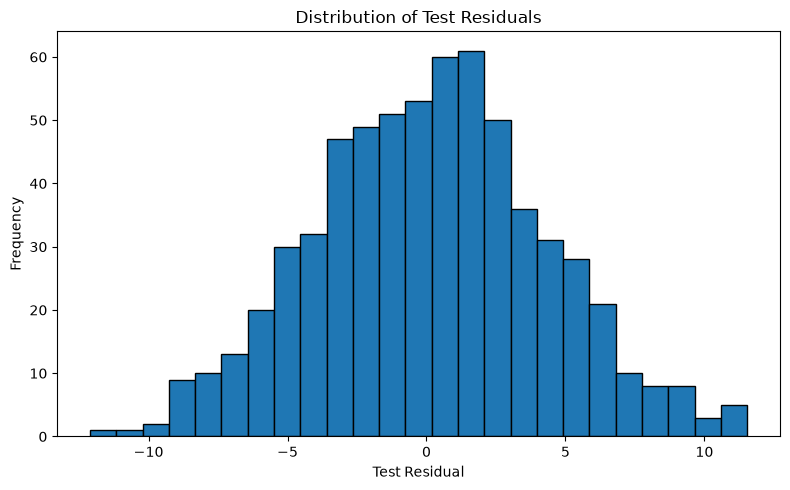

In [90]:
# ============================================================
# TEST RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.hist(
    test_residuals,
    bins=25,
    edgecolor="black"
)


plt.xlabel(
    "Test Residual"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of Test Residuals"
)

plt.tight_layout()
plt.show()

In [91]:
# ============================================================
# EXTRACT LINEAR REGRESSION COEFFICIENTS
# ============================================================

# Access the trained LinearRegression model
trained_linear_model = (
    model_pipeline
    .named_steps["model"]
)


# Obtain regression coefficients
coefficients = (
    trained_linear_model.coef_
)


# Obtain model intercept
model_intercept = (
    trained_linear_model.intercept_
)


# Build coefficient table
coefficient_table = pd.DataFrame(
    {
        "Feature":
            transformed_feature_names,

        "Coefficient":
            coefficients
    }
)


# Add absolute coefficient values only for sorting
coefficient_table[
    "Absolute_Coefficient"
] = (
    coefficient_table[
        "Coefficient"
    ]
    .abs()
)


# Sort strongest numerical coefficient magnitudes first
coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Model Intercept:",
    model_intercept
)


display(
    coefficient_table[
        [
            "Feature",
            "Coefficient"
        ]
    ].round(6)
)

Model Intercept: 6.587433061084255


,Feature,Coefficient
0,cat__Shipping_Mode_Standard,7.122704
1,cat__Shipping_Mode_Same-Day,-6.588742
2,cat__Product_Category_Home & Kitchen,1.617550
3,num__Traffic_Index,1.402821
4,num__Warehouse_Processing_Hours,1.140984
5,num__Courier_Load_Index,1.036048
6,num__Items_in_Order,0.527345
7,cat__Product_Category_Electronics,0.398039
8,num__Package_Weight_Kg,0.371642
9,cat__Product_Category_Fashion,-0.290106


In [92]:
# ============================================================
# IDENTIFY REFERENCE CATEGORIES
# ============================================================

# Access the fitted categorical OneHotEncoder
fitted_encoder = (
    model_pipeline
    .named_steps["preprocessing"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
)


# Display categories seen during training
print(
    "Product Category levels:",
    fitted_encoder.categories_[0]
)

print(
    "Shipping Mode levels:",
    fitted_encoder.categories_[1]
)


# Because drop="first" is used, the first alphabetical
# category in each set becomes the reference category.
print(
    "\nProduct Category reference:",
    fitted_encoder.categories_[0][0]
)

print(
    "Shipping Mode reference:",
    fitted_encoder.categories_[1][0]
)

Product Category levels: ['Beauty' 'Books' 'Electronics' 'Fashion' 'Home & Kitchen']
Shipping Mode levels: ['Express' 'Same-Day' 'Standard']

Product Category reference: Beauty
Shipping Mode reference: Express


In [93]:
# ============================================================
# CREATE FINAL DEPLOYMENT PIPELINE
# ============================================================

# Clone the already-defined model structure.
# This gives us a fresh, unfitted Pipeline with exactly
# the same preprocessing and Linear Regression configuration.

deployment_pipeline = clone(
    model_pipeline
)


# Fit the deployment pipeline using ALL usable corrected data.
#
# This is done only after train-test performance has already
# been evaluated and documented.
deployment_pipeline.fit(
    X,
    y
)


print(
    "Deployment pipeline fitted successfully on all",
    len(X),
    "usable observations."
)

Deployment pipeline fitted successfully on all 3192 usable observations.


In [94]:
# ============================================================
# SAVE FINAL DEPLOYMENT PIPELINE
# ============================================================

# Save preprocessing + encoding + Linear Regression
# together in one .pkl file.
joblib.dump(
    deployment_pipeline,
    "model.pkl"
)


print(
    "model.pkl saved successfully."
)

model.pkl saved successfully.


In [95]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

# Reload model.pkl from disk exactly as the
# Streamlit application will later do.
loaded_model = joblib.load(
    "model.pkl"
)


print(
    "model.pkl loaded successfully."
)

model.pkl loaded successfully.


In [96]:
# ============================================================
# TEST SAVED MODEL ON A NEW ORDER
# ============================================================

# Create one completely new observation using
# the exact predictor column names expected by the model.
test_order = pd.DataFrame(
    {
        "Product_Category": [
            "Electronics"
        ],

        "Shipping_Mode": [
            "Same-Day"
        ],

        "Order_Value": [
            6000.0
        ],

        "Package_Weight_Kg": [
            3.0
        ],

        "Warehouse_Distance_Km": [
            800.0
        ],

        "Items_in_Order": [
            4
        ],

        "Warehouse_Processing_Hours": [
            3.0
        ],

        "Courier_Load_Index": [
            5.0
        ],

        "Traffic_Index": [
            9.0
        ]
    }
)


# Generate prediction using the SAVED model
saved_model_prediction = (
    loaded_model.predict(
        test_order
    )[0]
)


print(
    "Prediction from saved model:",
    saved_model_prediction
)

print(
    "Rounded prediction:",
    round(saved_model_prediction, 2),
    "hours"
)

Prediction from saved model: 59.68688398433541
Rounded prediction: 59.69 hours


In [97]:
# ============================================================
# CREATE FINAL STREAMLIT APPLICATION
# ============================================================

# The entire Streamlit application is stored as text here.
# Running this cell will create/replace app.py in the same
# folder as this notebook and model.pkl.

app_code = '''
# ============================================================
# E-COMMERCE DELIVERY TIME PREDICTION APPLICATION
# ============================================================

# Streamlit creates the web application interface
import streamlit as st

# pandas is used to create the one-row DataFrame
# that will be passed to the trained model
import pandas as pd

# joblib loads the saved machine-learning pipeline
import joblib

# Path is used to reliably locate model.pkl
from pathlib import Path


# ------------------------------------------------------------
# PAGE CONFIGURATION
# ------------------------------------------------------------

# Configure the browser tab and page width
st.set_page_config(
    page_title="E-Commerce Delivery Time Predictor",
    page_icon="📦",
    layout="centered"
)


# ------------------------------------------------------------
# LOCATE AND LOAD THE TRAINED MODEL
# ------------------------------------------------------------

# Find the exact folder containing app.py
BASE_DIR = Path(__file__).resolve().parent

# model.pkl must be stored in the same folder
MODEL_PATH = BASE_DIR / "model.pkl"


# Load the saved preprocessing + regression pipeline
# safely so the application does not fail silently.
try:

    model = joblib.load(MODEL_PATH)

except Exception as error:

    st.error(
        f"Unable to load the prediction model: {error}"
    )

    # Stop the application because predictions cannot
    # be generated without the trained model.
    st.stop()


# ------------------------------------------------------------
# APPLICATION HEADING
# ------------------------------------------------------------

st.title(
    "📦 E-Commerce Delivery Time Predictor"
)

st.write(
    """
    This application estimates the expected delivery time of an
    e-commerce order using order, package, warehouse, courier,
    traffic and shipping information.
    """
)

st.caption(
    "Prediction output is expressed in hours."
)


# ------------------------------------------------------------
# USER INPUT SECTION
# ------------------------------------------------------------

st.subheader(
    "Enter Order Details"
)


# Use two columns to keep the application compact
left_column, right_column = st.columns(2)


# ------------------------------------------------------------
# LEFT-SIDE INPUTS
# ------------------------------------------------------------

with left_column:

    # Product category is a nominal categorical predictor.
    product_category = st.selectbox(
        "Product Category",
        [
            "Electronics",
            "Fashion",
            "Home & Kitchen",
            "Beauty",
            "Books"
        ]
    )


    # Shipping mode is a nominal categorical predictor.
    shipping_mode = st.selectbox(
        "Shipping Mode",
        [
            "Standard",
            "Express",
            "Same-Day"
        ]
    )


    # Order value:
    # The valid business range used for this project is
    # approximately ₹300 to ₹15,000.
    order_value = st.number_input(
        "Order Value (₹)",
        min_value=300.0,
        max_value=15000.0,
        value=6000.0,
        step=100.0
    )


    # Package weight:
    # Restricted to the valid project range.
    package_weight = st.number_input(
        "Package Weight (kg)",
        min_value=0.1,
        max_value=15.0,
        value=3.0,
        step=0.1
    )


    # Warehouse distance:
    # Restricted to the intended range represented by
    # the valid generated observations.
    warehouse_distance = st.number_input(
        "Warehouse Distance (km)",
        min_value=15.0,
        max_value=950.0,
        value=800.0,
        step=10.0
    )


# ------------------------------------------------------------
# RIGHT-SIDE INPUTS
# ------------------------------------------------------------

with right_column:

    # Number of items is an integer between 1 and 10.
    items_in_order = st.number_input(
        "Items in Order",
        min_value=1,
        max_value=10,
        value=4,
        step=1
    )


    # Valid warehouse processing time used in this project.
    warehouse_processing_hours = st.number_input(
        "Warehouse Processing Hours",
        min_value=0.5,
        max_value=6.0,
        value=3.0,
        step=0.1
    )


    # Courier Load Index uses a 1-10 scale.
    courier_load_index = st.number_input(
        "Courier Load Index",
        min_value=1.0,
        max_value=10.0,
        value=5.0,
        step=0.1
    )


    # Traffic Index also uses a 1-10 scale.
    traffic_index = st.number_input(
        "Traffic Index",
        min_value=1.0,
        max_value=10.0,
        value=9.0,
        step=0.1
    )


# ------------------------------------------------------------
# CREATE MODEL INPUT
# ------------------------------------------------------------

# IMPORTANT:
# These column names exactly match the predictor names
# used while training the saved machine-learning pipeline.
#
# Each value is placed inside a list because we are creating
# one new observation/row.

input_data = pd.DataFrame(
    {
        "Order_Value": [
            order_value
        ],

        "Package_Weight_Kg": [
            package_weight
        ],

        "Warehouse_Distance_Km": [
            warehouse_distance
        ],

        "Items_in_Order": [
            items_in_order
        ],

        "Warehouse_Processing_Hours": [
            warehouse_processing_hours
        ],

        "Courier_Load_Index": [
            courier_load_index
        ],

        "Traffic_Index": [
            traffic_index
        ],

        "Product_Category": [
            product_category
        ],

        "Shipping_Mode": [
            shipping_mode
        ]
    }
)


# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

st.markdown("---")


if st.button(
    "Predict Delivery Time",
    type="primary",
    use_container_width=True
):

    try:

        # Send the new order through the complete saved
        # preprocessing + Linear Regression pipeline.
        prediction = model.predict(
            input_data
        )[0]


        # Safety check:
        # delivery time cannot meaningfully be negative.
        if prediction <= 0:

            st.error(
                "The model generated an invalid non-positive "
                "delivery-time estimate."
            )

        else:

            # Display prediction prominently
            st.metric(
                label="Predicted Delivery Time",
                value=f"{prediction:.2f} hours"
            )


            # Provide the managerial interpretation required
            # by the assignment.
            st.info(
                f"""
                Based on the entered order and logistics conditions,
                the model estimates that this order will require
                approximately **{prediction:.2f} hours** for delivery.

                A manager can use this estimate for delivery planning,
                workload coordination and setting customer expectations.
                """
            )

    except Exception as error:

        # Clearly display any prediction failure rather than
        # allowing the application to fail silently.
        st.error(
            f"Prediction could not be generated: {error}"
        )


# ------------------------------------------------------------
# MODEL INFORMATION
# ------------------------------------------------------------

with st.expander(
    "About this prediction model"
):

    st.write(
        """
        The application uses a Multiple Linear Regression model.

        Numerical predictors:
        - Order Value
        - Package Weight
        - Warehouse Distance
        - Items in Order
        - Warehouse Processing Hours
        - Courier Load Index
        - Traffic Index

        Categorical predictors:
        - Product Category
        - Shipping Mode

        The saved model file contains both the preprocessing steps
        and the trained regression model, ensuring that new inputs
        are processed consistently with the training workflow.
        """
    )


# ------------------------------------------------------------
# COPYRIGHT
# ------------------------------------------------------------

st.markdown("---")

st.markdown(
    """
    <div style="text-align:center; font-size:0.82rem;">
        © 2026 Arin Bakshi. All Rights Reserved.<br>
        Unauthorized copying, modification, redistribution or
        commercial use of this project is prohibited without
        prior written permission.
    </div>
    """,
    unsafe_allow_html=True
)
'''


# ------------------------------------------------------------
# WRITE THE APPLICATION CODE INTO app.py
# ------------------------------------------------------------

with open(
    "app.py",
    "w",
    encoding="utf-8"
) as file:

    file.write(app_code)


print(
    "app.py created successfully."
)

app.py created successfully.


In [98]:
# ============================================================
# VERIFY DEPLOYMENT FILES
# ============================================================

import os


# Check whether the two essential deployment files exist
print(
    "app.py exists:",
    os.path.exists("app.py")
)

print(
    "model.pkl exists:",
    os.path.exists("model.pkl")
)


# Display file sizes as an additional verification
if os.path.exists("app.py"):

    print(
        "app.py size:",
        os.path.getsize("app.py"),
        "bytes"
    )


if os.path.exists("model.pkl"):

    print(
        "model.pkl size:",
        os.path.getsize("model.pkl"),
        "bytes"
    )

app.py exists: True
model.pkl exists: True
app.py size: 9115 bytes
model.pkl size: 4682 bytes


In [99]:
# ============================================================
# PREVIEW app.py
# ============================================================

# Open app.py in read-only mode
with open(
    "app.py",
    "r",
    encoding="utf-8"
) as file:

    # Read the entire application
    app_contents = file.read()


# Display only the first 1500 characters
# so we can confirm that the correct application was written.
print(
    app_contents[:1500]
)


# ============================================================
# E-COMMERCE DELIVERY TIME PREDICTION APPLICATION
# ============================================================

# Streamlit creates the web application interface
import streamlit as st

# pandas is used to create the one-row DataFrame
# that will be passed to the trained model
import pandas as pd

# joblib loads the saved machine-learning pipeline
import joblib

# Path is used to reliably locate model.pkl
from pathlib import Path


# ------------------------------------------------------------
# PAGE CONFIGURATION
# ------------------------------------------------------------

# Configure the browser tab and page width
st.set_page_config(
    page_title="E-Commerce Delivery Time Predictor",
    page_icon="📦",
    layout="centered"
)


# ------------------------------------------------------------
# LOCATE AND LOAD THE TRAINED MODEL
# ------------------------------------------------------------

# Find the exact folder co

In [100]:
# Show the exact project-folder location
import os

print(
    os.getcwd()
)

C:\Users\VISHAL\Desktop\AISPP ASSIGNMENT


In [101]:
# ============================================================
# CHECK EXACT DEPLOYMENT PACKAGE VERSIONS
# ============================================================

# sys gives us the exact Python version being used
import sys

# Import every major package required by the saved model/app
import streamlit
import pandas
import numpy
import sklearn
import scipy
import joblib
import threadpoolctl


# ------------------------------------------------------------
# DISPLAY EXACT VERSIONS
# ------------------------------------------------------------

print(
    "Python version:",
    sys.version
)

print(
    "Python major/minor:",
    f"{sys.version_info.major}.{sys.version_info.minor}"
)

print(
    "Streamlit:",
    streamlit.__version__
)

print(
    "Pandas:",
    pandas.__version__
)

print(
    "NumPy:",
    numpy.__version__
)

print(
    "Scikit-learn:",
    sklearn.__version__
)

print(
    "SciPy:",
    scipy.__version__
)

print(
    "Joblib:",
    joblib.__version__
)

print(
    "Threadpoolctl:",
    threadpoolctl.__version__
)

Python version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Python major/minor: 3.14
Streamlit: 1.58.0
Pandas: 3.0.3
NumPy: 2.4.6
Scikit-learn: 1.9.0
SciPy: 1.18.0
Joblib: 1.5.3
Threadpoolctl: 3.5.0


In [102]:
# ============================================================
# CREATE FINAL requirements.txt
# ============================================================

# Pin the exact package versions used by the current
# working environment.
#
# This is particularly important for scikit-learn because
# model.pkl was created using the installed sklearn version.

requirements = [

    f"streamlit=={streamlit.__version__}",

    f"pandas=={pandas.__version__}",

    f"numpy=={numpy.__version__}",

    f"scikit-learn=={sklearn.__version__}",

    f"scipy=={scipy.__version__}",

    f"joblib=={joblib.__version__}",

    f"threadpoolctl=={threadpoolctl.__version__}"
]


# Write the package list into requirements.txt
with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "\n".join(requirements)
    )


print(
    "requirements.txt created successfully."
)


# ------------------------------------------------------------
# VERIFY CONTENTS
# ------------------------------------------------------------

with open(
    "requirements.txt",
    "r",
    encoding="utf-8"
) as file:

    print(
        "\nFinal requirements.txt:\n"
    )

    print(
        file.read()
    )

requirements.txt created successfully.

Final requirements.txt:

streamlit==1.58.0
pandas==3.0.3
numpy==2.4.6
scikit-learn==1.9.0
scipy==1.18.0
joblib==1.5.3
threadpoolctl==3.5.0


In [103]:
# ============================================================
# VERIFY FINAL PROJECT FILES
# ============================================================

import os


required_files = [
    "app.py",
    "model.pkl",
    "requirements.txt",
    "ecommerce_delivery_unclean_data_3232.csv"
]


print(
    "FINAL FILE CHECK"
)

print(
    "----------------"
)


for file in required_files:

    print(
        f"{file}:",
        "FOUND"
        if os.path.exists(file)
        else "MISSING"
    )

FINAL FILE CHECK
----------------
app.py: FOUND
model.pkl: FOUND
requirements.txt: FOUND
ecommerce_delivery_unclean_data_3232.csv: FOUND


In [104]:
# ============================================================
# FINAL PROJECT SUBMISSION AUDIT
# ============================================================

import os


# ------------------------------------------------------------
# FILES REQUIRED FOR THE ASSIGNMENT / DEPLOYMENT
# ------------------------------------------------------------

# Change the notebook filename below ONLY if your current
# notebook has a different name.
required_project_files = [
    "app.py",
    "model.pkl",
    "requirements.txt",
    "ecommerce_delivery_unclean_data_3232.csv",
    "model_training_3232.ipynb",
    "README.md"
]


print("FINAL PROJECT FILE AUDIT")
print("------------------------")


all_required_files_found = True


for file in required_project_files:

    exists = os.path.exists(file)

    print(
        f"{file}:",
        "FOUND"
        if exists
        else "MISSING"
    )

    if not exists:
        all_required_files_found = False


# ------------------------------------------------------------
# CHECK SCREENSHOT FOLDER
# ------------------------------------------------------------

print("\nSCREENSHOT CHECK")
print("----------------")


screenshots_folder_exists = os.path.isdir(
    "screenshots"
)

print(
    "screenshots folder:",
    "FOUND"
    if screenshots_folder_exists
    else "MISSING"
)


# Check the verified application prediction screenshot
prediction_screenshot = (
    "screenshots/app_prediction.png"
)

prediction_screenshot_exists = os.path.exists(
    prediction_screenshot
)

print(
    "app_prediction.png:",
    "FOUND"
    if prediction_screenshot_exists
    else "MISSING"
)


# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

submission_ready = (
    all_required_files_found
    and
    screenshots_folder_exists
    and
    prediction_screenshot_exists
)


print("\nFINAL STATUS")
print("------------")


if submission_ready:

    print(
        "All essential project files are present."
    )

else:

    print(
        "One or more essential files are still missing."
    )

FINAL PROJECT FILE AUDIT
------------------------
app.py: FOUND
model.pkl: FOUND
requirements.txt: FOUND
ecommerce_delivery_unclean_data_3232.csv: FOUND
model_training_3232.ipynb: FOUND
README.md: FOUND

SCREENSHOT CHECK
----------------
screenshots folder: FOUND
app_prediction.png: FOUND

FINAL STATUS
------------
All essential project files are present.


In [105]:
# ============================================================
# DISPLAY FINAL requirements.txt
# ============================================================

# Open requirements.txt so we can verify the exact
# package versions before uploading to Streamlit Cloud.
with open(
    "requirements.txt",
    "r",
    encoding="utf-8"
) as file:

    print(
        file.read()
    )

streamlit==1.58.0
pandas==3.0.3
numpy==2.4.6
scikit-learn==1.9.0
scipy==1.18.0
joblib==1.5.3
threadpoolctl==3.5.0


In [106]:
# ============================================================
# FINAL PYTHON VERSION CHECK
# ============================================================

# sys tells us the exact Python version used to train
# and save model.pkl in this notebook environment.
import sys

print(
    "Full Python Version:",
    sys.version
)

print(
    "Python Version for Streamlit:",
    f"{sys.version_info.major}.{sys.version_info.minor}"
)

Full Python Version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Python Version for Streamlit: 3.14


In [109]:
# ============================================================
# CREATE FINAL README.md - SAFE VERSION
# ============================================================

# This version avoids nested Markdown code fences so that
# the Python multiline string is copied into Jupyter safely.

readme_content = '''# E-Commerce Delivery Time Prediction

## Project Overview

This project develops and deploys a Multiple Linear Regression model to
predict e-commerce delivery time in hours using order, package, warehouse,
courier, traffic, product-category and shipping information.

The project covers the complete workflow from raw data-quality assessment
and regression-assumption diagnosis to model evaluation and deployment
through an interactive Streamlit web application.

---

## Business Objective

The objective is to estimate the expected delivery time of a new
e-commerce order.

The prediction can support managers in:

- Delivery planning
- Logistics coordination
- Courier workload planning
- Setting customer delivery expectations

---

## Target Variable

`Delivery_Time_Hours`

The predicted output is expressed in **hours**.

---

## Predictor Variables

### Numerical Predictors

- `Order_Value`
- `Package_Weight_Kg`
- `Warehouse_Distance_Km`
- `Items_in_Order`
- `Warehouse_Processing_Hours`
- `Courier_Load_Index`
- `Traffic_Index`

### Categorical Predictors

- `Product_Category`
- `Shipping_Mode`

`Order_ID` is treated only as an identifier and is not used as a
regression predictor.

---

## Dataset

The raw dataset contains:

- **3,232 rows**
- **11 columns**
- **3,200 unique Order IDs**

After removing exact duplicate records and observations with missing target
values, **3,192 usable observations** remained.

The raw dataset intentionally contains data-quality issues so that the
complete cleaning and regression-diagnostic workflow can be demonstrated.

---

## Data Preparation

The following checks and treatments were performed:

- Missing-value detection
- Exact duplicate detection and removal
- Identification of the target, predictors and identifier
- Standardization of inconsistent categorical values
- Detection of logically impossible numerical values
- Treatment of invalid predictor values as missing
- Median treatment for numerical missing values
- Most-frequent-category treatment for categorical missing values
- IQR-based outlier investigation
- Standardized residual analysis
- Leverage analysis
- Cook's Distance analysis
- Correction of confirmed data-entry errors

Potential statistical outliers were investigated rather than automatically
removed.

---

## Linear Regression Assumption Checks

The project evaluates the major assumptions of Multiple Linear Regression
using:

- Linearity plots
- Correlation analysis
- Variance Inflation Factor (VIF)
- Mean of residuals
- Durbin-Watson statistic
- Residuals-versus-fitted plot
- Breusch-Pagan test
- Residual histogram
- Q-Q plot
- Jarque-Bera test
- Standardized residuals
- Leverage
- Cook's Distance

After confirmed data-entry corrections, the regression assumptions were
re-checked.

### Assumption Results After Corrections

| Diagnostic | Result |
|---|---:|
| OLS R-squared | 0.925365 |
| OLS Adjusted R-squared | 0.925060 |
| Durbin-Watson | 1.982046 |
| Breusch-Pagan p-value | 0.308044 |
| Jarque-Bera p-value | 0.640915 |
| Residual Skewness | 0.032176 |
| Residual Kurtosis | 2.949517 |

The post-correction residual diagnostics showed substantial improvement
compared with the initial uncorrected regression.

---

## Machine Learning Workflow

The final predictive workflow uses an **80/20 train-test split** with
`random_state=42`.

A scikit-learn Pipeline is used so that preprocessing and prediction are
performed consistently.

### Numerical Processing

Missing numerical predictor values are imputed using the median learned
from the training data.

### Categorical Processing

Missing categorical values are imputed using the most frequent category.

Categorical predictors are encoded using:

`OneHotEncoder(drop="first", handle_unknown="ignore")`

### Model

`LinearRegression`

---

## Model Performance

The final train-test evaluation produced:

| Metric | Value |
|---|---:|
| Training R-squared | 0.927116 |
| Training Adjusted R-squared | 0.926743 |
| Test R-squared | 0.917740 |
| Test MAE | 3.325331 hours |
| Test MSE | 17.180302 |
| Test RMSE | 4.144913 hours |

The test R-squared indicates that approximately **91.77% of the variation
in delivery time in the unseen test observations is explained by the
model**.

The Mean Absolute Error indicates an average absolute prediction error of
approximately **3.33 hours** on the test set.

---

## Saved Model

The complete preprocessing and Linear Regression workflow is saved as:

`model.pkl`

The saved object contains:

- Numerical missing-value treatment
- Categorical missing-value treatment
- One-hot encoding
- Multiple Linear Regression

After model evaluation was completed, the deployment version of the
pipeline was fitted on all **3,192 usable observations**.

---

## Streamlit Application

The Streamlit application:

- Loads the saved `model.pkl`
- Does not retrain the model when the application starts
- Accepts all required predictor values
- Performs basic input validation
- Generates predictions for new orders
- Displays delivery time in hours
- Provides a managerial interpretation of the result

### Verified Prediction

The application was verified using:

- Product Category: Electronics
- Shipping Mode: Same-Day
- Order Value: ₹6,000
- Package Weight: 3 kg
- Warehouse Distance: 800 km
- Items in Order: 4
- Warehouse Processing Hours: 3 hours
- Courier Load Index: 5
- Traffic Index: 9

The saved deployment model produced:

**59.69 hours**

---

## Application Screenshot

![Working Streamlit Prediction](screenshots/app_prediction.png)

---

## Project Structure

Project files:

- `ecommerce_delivery_unclean_data_3232.csv`
- `model_training_3232.ipynb`
- `model.pkl`
- `app.py`
- `requirements.txt`
- `README.md`
- `screenshots/app_prediction.png`

---

## Running the Application Locally

### Step 1 - Install Dependencies

Run:

`pip install -r requirements.txt`

### Step 2 - Start the Streamlit Application

Run:

`python -m streamlit run app.py`

### Step 3 - Open the Application

Streamlit will provide a local address, normally:

`http://localhost:8501`

---

## Important Usage Note

The application can generate predictions for new orders that were not
present in the training dataset.

Predictions are most reliable when predictor values remain within or
reasonably close to the ranges represented by the training data.

---

## Copyright

© 2026 Arin Bakshi. All Rights Reserved.

This project's original source code, documentation, application interface,
and project-specific model files may not be copied, modified,
redistributed, published or used commercially without prior written
permission from the author.

Third-party libraries, frameworks, course materials and externally sourced
components remain subject to their respective licenses and ownership.
'''


# ------------------------------------------------------------
# WRITE THE README FILE
# ------------------------------------------------------------

# Open README.md in write mode.
# This intentionally replaces the older README with the
# final version for the new 3,232-row project.
with open(
    "README.md",
    "w",
    encoding="utf-8"
) as file:

    file.write(readme_content)


print(
    "Final README.md created successfully."
)

Final README.md created successfully.


In [110]:
# ============================================================
# VERIFY THAT README.md WAS WRITTEN CORRECTLY
# ============================================================

# Read the completed README from disk
with open(
    "README.md",
    "r",
    encoding="utf-8"
) as file:

    readme_check = file.read()


# Display useful checks
print(
    "README.md exists:",
    os.path.exists("README.md")
)

print(
    "README length:",
    len(readme_check),
    "characters"
)

print(
    "\nREADME starts with:\n"
)

print(
    readme_check[:1000]
)


# ------------------------------------------------------------
# VERIFY IMPORTANT FINAL VALUES ARE PRESENT
# ------------------------------------------------------------

required_readme_text = [
    "3,232 rows",
    "3,192 usable observations",
    "0.917740",
    "3.325331 hours",
    "4.144913 hours",
    "59.69 hours"
]


print(
    "\nFINAL README CONTENT CHECK"
)

print(
    "--------------------------"
)


for text in required_readme_text:

    print(
        f"{text}:",
        "FOUND"
        if text in readme_check
        else "MISSING"
    )

README.md exists: True
README length: 6782 characters

README starts with:

# E-Commerce Delivery Time Prediction

## Project Overview

This project develops and deploys a Multiple Linear Regression model to
predict e-commerce delivery time in hours using order, package, warehouse,
courier, traffic, product-category and shipping information.

The project covers the complete workflow from raw data-quality assessment
and regression-assumption diagnosis to model evaluation and deployment
through an interactive Streamlit web application.

---

## Business Objective

The objective is to estimate the expected delivery time of a new
e-commerce order.

The prediction can support managers in:

- Delivery planning
- Logistics coordination
- Courier workload planning
- Setting customer delivery expectations

---

## Target Variable

`Delivery_Time_Hours`

The predicted output is expressed in **hours**.

---

## Predictor Variables

### Numerical Predictors

- `Order_Value`
- `Package_Weight_Kg`
-

In [111]:
# ============================================================
# FINAL PRE-DEPLOYMENT AUDIT
# ============================================================

# os checks that required project files exist
import os

# sys gives the exact Python version used by this notebook
import sys

# joblib lets us verify that the saved model still loads
import joblib

# pandas is required for the smoke-test observation
import pandas as pd


# ------------------------------------------------------------
# 1. CHECK ESSENTIAL FILES
# ------------------------------------------------------------

required_files = [
    "app.py",
    "model.pkl",
    "requirements.txt",
    "README.md",
    "model_training_3232.ipynb",
    "ecommerce_delivery_unclean_data_3232.csv",
    "screenshots/app_prediction.png"
]


print("FILE CHECK")
print("----------")

all_files_found = True

for file in required_files:

    exists = os.path.exists(file)

    print(
        f"{file}:",
        "FOUND" if exists else "MISSING"
    )

    if not exists:
        all_files_found = False


# ------------------------------------------------------------
# 2. CHECK IMPORTANT README CONTENT
# ------------------------------------------------------------

with open(
    "README.md",
    "r",
    encoding="utf-8"
) as file:

    readme_text = file.read()


required_readme_items = [
    "3,232 rows",
    "3,192 usable observations",
    "0.917740",
    "3.325331 hours",
    "4.144913 hours",
    "59.69 hours",
    "screenshots/app_prediction.png"
]


print("\nREADME CHECK")
print("------------")

all_readme_items_found = True

for item in required_readme_items:

    found = item in readme_text

    print(
        f"{item}:",
        "FOUND" if found else "MISSING"
    )

    if not found:
        all_readme_items_found = False


# ------------------------------------------------------------
# 3. DISPLAY PYTHON VERSION
# ------------------------------------------------------------

print("\nPYTHON VERSION")
print("--------------")

print(
    "Full version:",
    sys.version
)

print(
    "Version to use for Streamlit:",
    f"{sys.version_info.major}.{sys.version_info.minor}"
)


# ------------------------------------------------------------
# 4. FINAL MODEL SMOKE TEST
# ------------------------------------------------------------

# Load the saved deployment model
audit_model = joblib.load(
    "model.pkl"
)


# Use the exact verified order from our previous test
audit_order = pd.DataFrame(
    {
        "Order_Value": [6000.0],
        "Package_Weight_Kg": [3.0],
        "Warehouse_Distance_Km": [800.0],
        "Items_in_Order": [4],
        "Warehouse_Processing_Hours": [3.0],
        "Courier_Load_Index": [5.0],
        "Traffic_Index": [9.0],
        "Product_Category": ["Electronics"],
        "Shipping_Mode": ["Same-Day"]
    }
)


audit_prediction = audit_model.predict(
    audit_order
)[0]


print("\nMODEL CHECK")
print("-----------")

print(
    "Prediction:",
    round(audit_prediction, 2),
    "hours"
)


# ------------------------------------------------------------
# 5. FINAL STATUS
# ------------------------------------------------------------

print("\nFINAL LOCAL STATUS")
print("------------------")

if (
    all_files_found
    and
    all_readme_items_found
    and
    round(audit_prediction, 2) == 59.69
):

    print(
        "LOCAL PROJECT PASSED ALL CHECKS."
    )

else:

    print(
        "STOP: One or more checks failed."
    )

FILE CHECK
----------
app.py: FOUND
model.pkl: FOUND
requirements.txt: FOUND
README.md: FOUND
model_training_3232.ipynb: FOUND
ecommerce_delivery_unclean_data_3232.csv: FOUND
screenshots/app_prediction.png: FOUND

README CHECK
------------
3,232 rows: FOUND
3,192 usable observations: FOUND
0.917740: FOUND
3.325331 hours: FOUND
4.144913 hours: FOUND
59.69 hours: FOUND
screenshots/app_prediction.png: FOUND

PYTHON VERSION
--------------
Full version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Version to use for Streamlit: 3.14

MODEL CHECK
-----------
Prediction: 59.69 hours

FINAL LOCAL STATUS
------------------
LOCAL PROJECT PASSED ALL CHECKS.
